# Analytics - Product Quality

#### Date: 2020/02

#### SUMMARY:

- This notebook represents the project quality analysis of the date exposed right above. 

### TEAM:

##### Semester: YYYY/0X
##### Professor: Hilmer Neri

##### Members:

- Member x
- Member y


### LIBRARIES

In [57]:
# Deal with data
import pandas as pd
import json
from glob import glob
import os

# Deal with visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Deal with type hints
from typing import List

# Deal with time
import datetime

### GRAPH SETTINGS

In [58]:
%config InlineBackend.figure_format ='retina'
sns.set(font_scale=1.5)
sns.set_style('darkgrid',
              {'xtick.bottom' : True,
               'ytick.left': True,
               'grid.linestyle':'--',
               'font.monospace': ['Computer Modern Typewriter'],
               'axes.edgecolor' : 'white'})

### DATAFRAME SETTINGS

In [59]:
pd.set_option("display.max_rows", None, "display.max_columns", None)

#### Replace your semester, project name, repository name, and the programming language extension

In [60]:
# Set your repo major name here
# Example: fga-eps-mds-2024.1-MeasureSoftGram-
# repo_name = 'fga-eps-mds-2021-1-YourProjectName-'
repo_name = 'fga-eps-mds-2024.1-MeasureSoftGram-'
# Add your repos here
# Example: 'Front': 'py',                               # Ajeitar Célula
repos_language = {
    'Core': 'py',
    'Service': 'py',
    'Front': 'ts',
    # 'YourRepoName': 'py',
}

### SonarCloud
##### Path to the folder with all your jsons

In [61]:
# Maybe you should change this path to your own path

sonar_files = glob('./analytics-raw-data/sonar-cloud/fga-eps-mds-*.json')

## Create DataFrame

#### Unmarshall json

In [62]:
def unmarshall(json_path: str) -> dict:
    with open(json_path) as json_file:
        json_obj = json.load(json_file)
    return json_obj

#### Create a list with all valid columns

In [63]:
metric_list = [
    'files',
    'functions',
    'complexity',
    'comment_lines_density',
    'duplicated_lines_density',
    'coverage',
    'ncloc',
    'tests',
    'test_errors',
    'test_failures',
    'test_execution_time',
    'security_rating',
    'blocker_violations',
    'critical_violations',
    'bugs'
    ]

#### Extract files dataframe out of component dataframe

In [64]:
def get_files_df(df: pd.DataFrame) -> pd.DataFrame:
    files_df = df[df['qualifier'] == 'FIL']

    files_df = files_df.dropna(subset=['functions', 'complexity','comment_lines_density', 'duplicated_lines_density', 'coverage' ])

    return files_df

#### Extract directories dataframe out of component dataframe

In [65]:
def get_dir_df(df: pd.DataFrame) -> pd.DataFrame:
    dirs = df[df["qualifier"] == "DIR"]

    newdf = pd.to_numeric(dirs["tests"])

    max_value_index = newdf.idxmax()

    return dirs.loc[max_value_index]

#### Extract uts dataframe out of component dataframe

In [66]:
def get_uts_df(df: pd.DataFrame) -> pd.DataFrame:
    uts_df = df[df['qualifier'] == 'UTS']

    uts_df = uts_df.fillna(0)

    uts_df = uts_df.dropna(subset=['test_execution_time'])

    return uts_df

#### Generate component dataframe

In [67]:
def metric_per_file(json_dict: dict) -> List[dict]:
    file_json = []

    for component in json_dict['components']:
        ncloc_value = 0
        for measure in component['measures']:
            if measure['metric'] == 'ncloc':
                ncloc_value = float(measure['value'])
                break

        if (component['qualifier'] == 'FIL' and ncloc_value > 0) \
                or component['qualifier'] == 'DIR' \
                or component['qualifier'] == 'UTS':
            file_json.append(component)

    return file_json


def generate_component_dataframe_data(
        metrics_list: List[str],
        file_component_data: List[dict],
        language_extension: str) -> pd.DataFrame:

    df_columns = metrics_list

    files_df = pd.DataFrame(columns = df_columns)
    dirs_df = pd.DataFrame(columns = df_columns)
    uts_df = pd.DataFrame(columns = df_columns)

    for file in file_component_data:
        try:
                if file['qualifier'] == 'FIL' and file['language'] == language_extension:
                    for measure in file['measures']:
                        files_df.at[file['path'], measure['metric']] = measure['value']

                    files_df['qualifier'] = file['qualifier']

                elif file['qualifier'] == 'DIR':
                    for measure in file['measures']:
                        dirs_df.at[file['path'], measure['metric']] = measure['value']

                    dirs_df['qualifier'] = file['qualifier']

                elif file['qualifier'] == 'UTS':
                    for measure in file['measures']:
                        uts_df.at[file['path'], measure['metric']] = measure['value']

                    uts_df['qualifier'] = file['qualifier']

        except:
            pass

    files_df.reset_index(inplace = True)
    dirs_df.reset_index(inplace = True)
    uts_df.reset_index(inplace = True)

    files_df = files_df.rename({'index': 'path'}, axis=1)
    dirs_df = dirs_df.rename({'index': 'path'}, axis=1)
    uts_df = uts_df.rename({'index': 'path'}, axis=1)

    df = pd.concat([files_df, dirs_df, uts_df], axis=0)

    return df


def create_component_df(json_list):
    df = pd.DataFrame()

    for json_path in json_list:
        file_component = unmarshall(json_path)
        file_component_data = metric_per_file(file_component)

        base_name = os.path.basename(json_path)

        file_component_dataframe = generate_component_dataframe_data(
            metric_list,
            file_component_data,
            language_extension = repos_language[base_name.split("-")[5]])


        file_component_dataframe['filename'] = base_name

        df = pd.concat([df, file_component_dataframe], ignore_index=True)

    aux_df = df['filename'].str.split(r"-(\d+-\d+-\d+-\d+-\d+-\d+)-(.*?).json", expand=True)
    df['repository'] = aux_df[0]
    df['datetime'] = aux_df[1]
    df['version'] = aux_df[2]

    df = df.sort_values(by=['repository', 'datetime'])

    return df

In [69]:
file_component_df = create_component_df(sonar_files)
file_component_df = file_component_df[~file_component_df.path.str.contains("__init__") & ~file_component_df.path.str.contains("staticfiles")]
file_component_df.repository.unique()

array(['fga-eps-mds-2024.1-MeasureSoftGram-Core',
       'fga-eps-mds-2024.1-MeasureSoftGram-Front',
       'fga-eps-mds-2024.1-MeasureSoftGram-Service'], dtype=object)

### Create dataframe per repository

In [ ]:
repos_dataframes = []

for repo in repos_language.keys():
    dataframe = file_component_df[file_component_df['repository'] == repo_name+repo]
    repos_dataframes.append({'name': repo, 'df': dataframe})

Index(['path', 'files', 'functions', 'complexity', 'comment_lines_density',
       'duplicated_lines_density', 'coverage', 'ncloc', 'tests', 'test_errors',
       'test_failures', 'test_execution_time', 'security_rating',
       'blocker_violations', 'critical_violations', 'bugs', 'qualifier',
       'filename', 'repository', 'datetime', 'version'],
      dtype='object')
Index(['path', 'files', 'functions', 'complexity', 'comment_lines_density',
       'duplicated_lines_density', 'coverage', 'ncloc', 'tests', 'test_errors',
       'test_failures', 'test_execution_time', 'security_rating',
       'blocker_violations', 'critical_violations', 'bugs', 'qualifier',
       'filename', 'repository', 'datetime', 'version'],
      dtype='object')
Index(['path', 'files', 'functions', 'complexity', 'comment_lines_density',
       'duplicated_lines_density', 'coverage', 'ncloc', 'tests', 'test_errors',
       'test_failures', 'test_execution_time', 'security_rating',
       'blocker_violations', '

## Measure calculations according to Q-Rapids quality model

In [71]:
def _ncloc(df: pd.DataFrame) -> int:
    ncloc = 0
    for each in df['ncloc']:
        # try to cast the current ncloc value to int, if the value is NaN/Null, consider it as zero.
        try:
            n = int(each)
        except ValueError:
            n = 0
        ncloc += n

    return ncloc

## Quality Aspect - Maintainability

### Factor - Code Quality

#### Complexity

In [72]:
def complexity(df: pd.DataFrame):

    files_df = get_files_df(df)

    density_non_complex_files = len(files_df[(files_df['complexity'].astype(float) /
                                    files_df['functions'].astype(float)) < 10]) / len(files_df)

    return density_non_complex_files

#### Comments

In [73]:
def comments(df: pd.DataFrame):

    files_df = get_files_df(df)

    density_comment_files = len(files_df[(files_df['comment_lines_density'].astype(float) > 10) &
                                         (files_df['comment_lines_density'].astype(float) < 30)]) / len(files_df)

    return density_comment_files

#### Duplications

In [74]:
def duplication(df: pd.DataFrame):

    files_df = get_files_df(df)

    duplication = len(files_df[(files_df['duplicated_lines_density'].astype(float) < 5)])/len(files_df)

    return duplication

### Factor - Blocking Code

In [75]:
def fulfillment(df: pd.DataFrame):
    files_df = get_files_df(df)

    df["blocker_violations"] = df["blocker_violations"].astype(int)
    df["critical_violations"] = df["critical_violations"].astype(int)
    fulfillment = df[(df["critical_violations"] > 0) | (df["blocker_violations"] > 0)]["files"].count() / files_df["files"].count()

    return fulfillment

## Quality Aspect - Reliability

### Factor - Software Stability

In [76]:
def bug_density_per_LOC(df: pd.DataFrame):
    # Bug Density LOC = bugs / ncloc
    files_df = get_files_df(df)
    
    files_df['bugs'] = files_df['bugs'].astype(float)
    bug_density = 1 - files_df['bugs'].sum() / _ncloc(files_df)

    return bug_density

### Factor - Testing Status

#### Passed tests

In [77]:
def test_success(df: pd.DataFrame):

    dir_df = get_dir_df(df)

    passed_tests = (float(dir_df['tests']) - (float(dir_df['test_errors']) + float(dir_df['test_failures']))) /\
               float(dir_df['tests'])

    return passed_tests

#### Fast test builds

In [78]:
def fast_tests(df: pd.DataFrame):
    dir_df = get_uts_df(df)

    density_fast_test_builds = len(dir_df[(dir_df['test_execution_time'].astype(float)) < 300000]) /\
                                len(dir_df['test_execution_time'].astype(float))
    return density_fast_test_builds

#### Test coverage

In [79]:
def coverage(df: pd.DataFrame):

    files_df = get_files_df(df)

    density_test_coverage = len(files_df[(files_df['coverage'].astype(float) > 60)]) / len(files_df)

    return density_test_coverage

## Calculate measures for each repository

In [ ]:
def create_metrics_df(df: pd.DataFrame) -> pd.DataFrame:
    date_time_vec = df['datetime'].unique()

    m1_list = []
    m2_list = []
    m3_list = []
    m4_list = []
    m5_list = []
    m6_list = []
    
    bug_density_list = []
    fulfillment_list = []

    ncloc_list = []
    repository_list = []
    version_list = []

    for version in date_time_vec:
        version_df = df[df['datetime'] == version]

        try:
            m1_list.append(complexity(version_df))
        except Exception:
            m1_list.append(0)

        try:
            m2_list.append(comments(version_df))
        except Exception:
            m2_list.append(0)

        try:
            m3_list.append(duplication(version_df))
        except Exception:
            m3_list.append(0)

        try:
            m4_list.append(test_success(version_df))
        except Exception:
            m4_list.append(0)

        try:
            m5_list.append(fast_tests(version_df))
        except Exception:
            m5_list.append(0)

        try:
            m6_list.append(coverage(version_df))
        except Exception:
            m6_list.append(0)

        try:
            bug_density_list.append(bug_density_per_LOC(version_df))  
        except Exception as e:
            bug_density_list.append(0)

        try:
            fulfillment_list.append(fulfillment(version_df))
        except Exception as e:
            fulfillment_list.append(0)



        ncloc_list.append(_ncloc(version_df))
        repository_list.append(version_df['repository'].iloc[0])
        version_list.append(version)

    final_dict = {
        'complexity': m1_list,
        'comments': m2_list,
        'duplication': m3_list,
        'test_success': m4_list,
        'fast_tests': m5_list,
        'coverage': m6_list,
        'bug_density_per_LOC': bug_density_list,
        'fulfillment': fulfillment_list,
        'repository': repository_list,
        'version': version_list,
        'ncloc': ncloc_list
    }

    metrics_df = pd.DataFrame(final_dict)

    return metrics_df


In [82]:
# Here we will create a dictionary with the metrics for each repository
metrics = {}

for repo_df in repos_dataframes:
    metrics[repo_df['name']] = create_metrics_df(repo_df['df'])

C:\Users\pedro\AppData\Local\Temp\ipykernel_836\1196986679.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  uts_df = uts_df.fillna(0)
C:\Users\pedro\AppData\Local\Temp\ipykernel_836\721574429.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["blocker_violations"] = df["blocker_violations"].astype(int)
C:\Users\pedro\AppData\Local\Temp\ipykernel_836\721574429.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

## Data visualization

In this area you will need to plot the metrics of each repository.

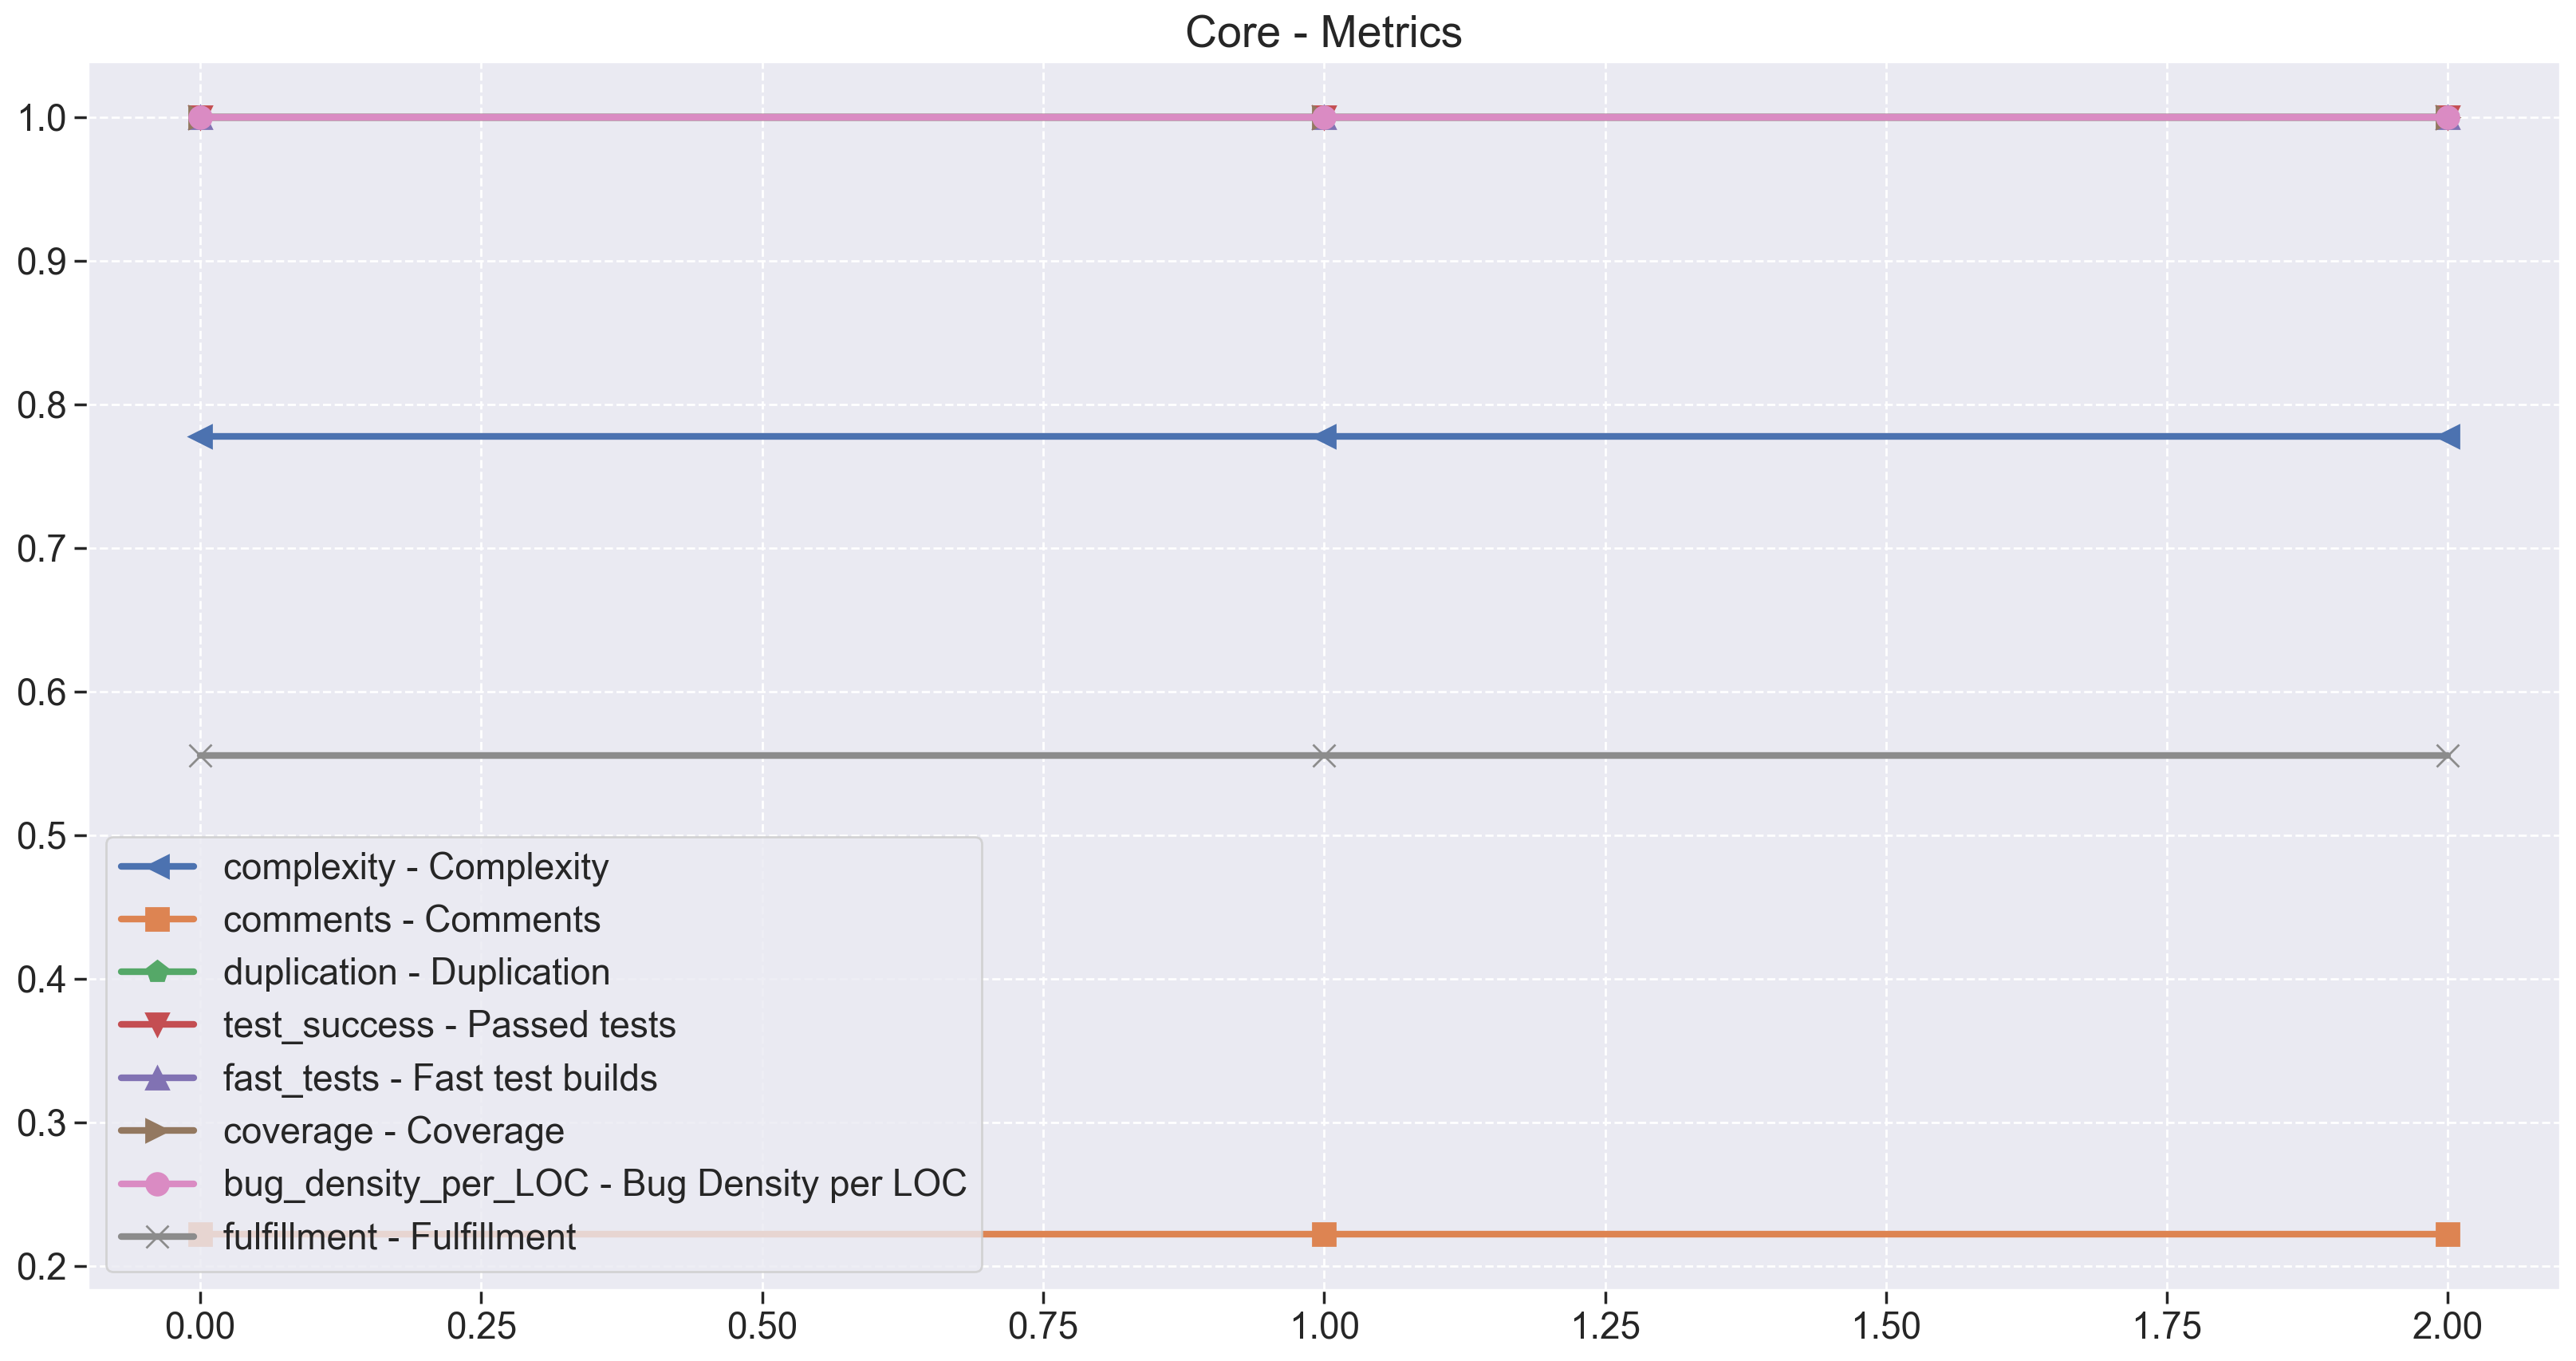

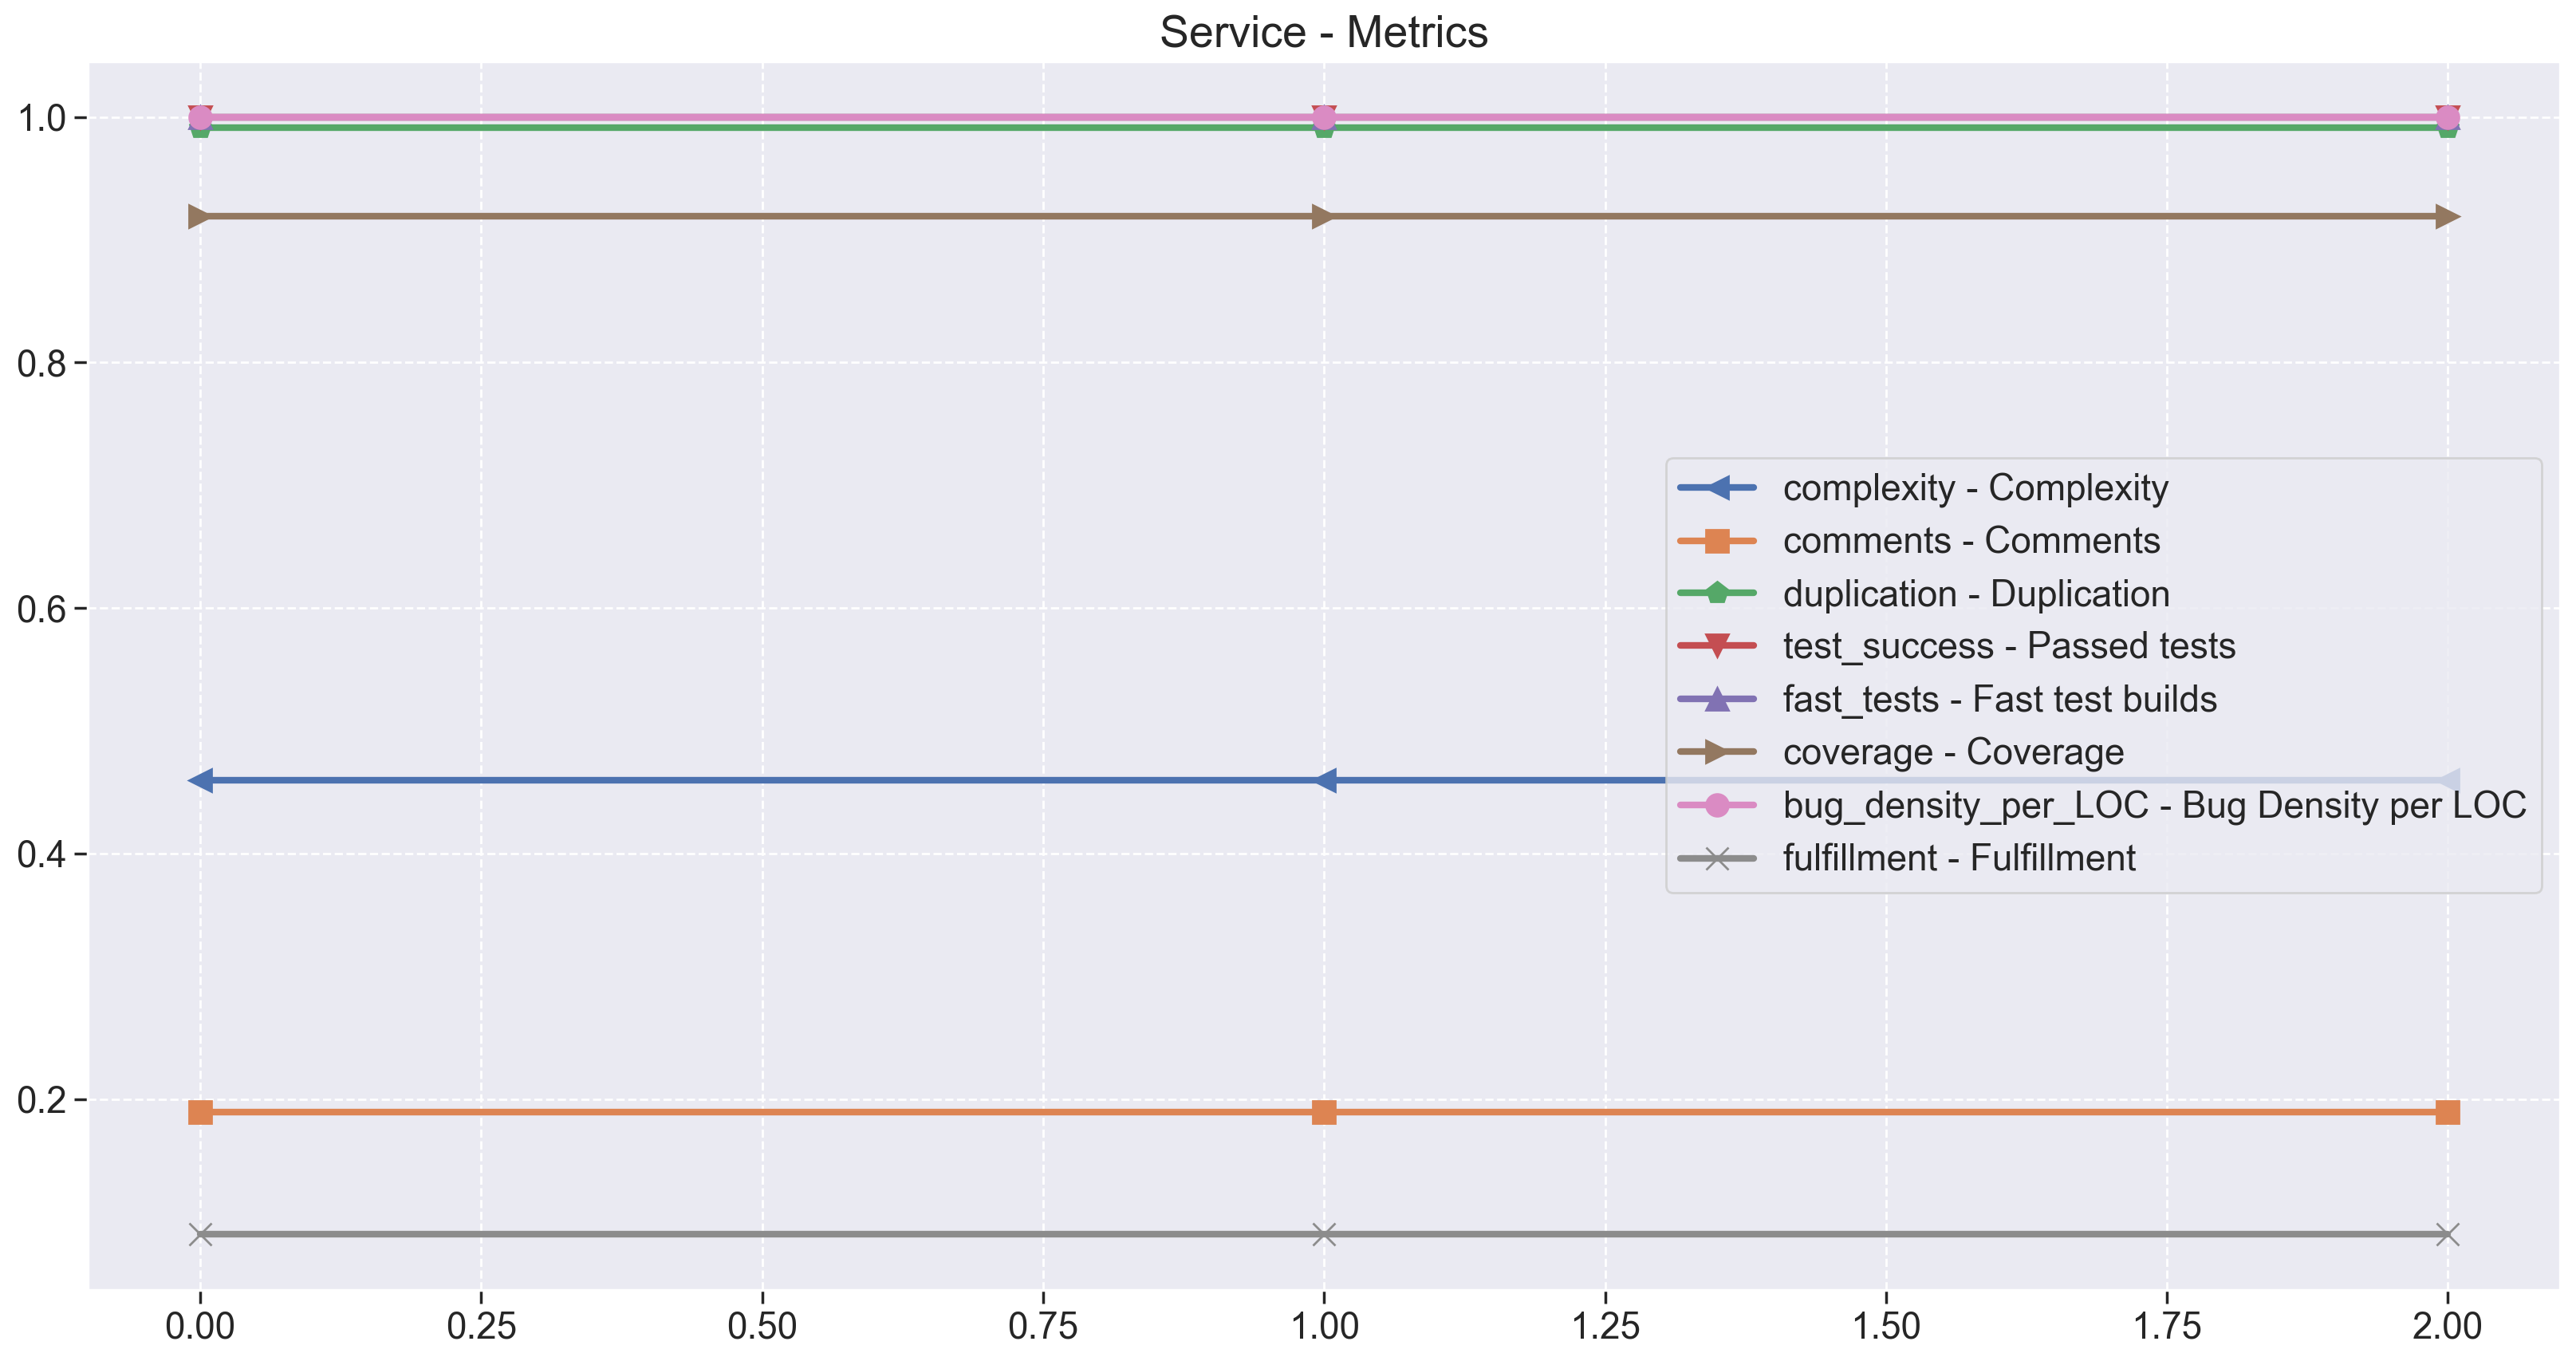

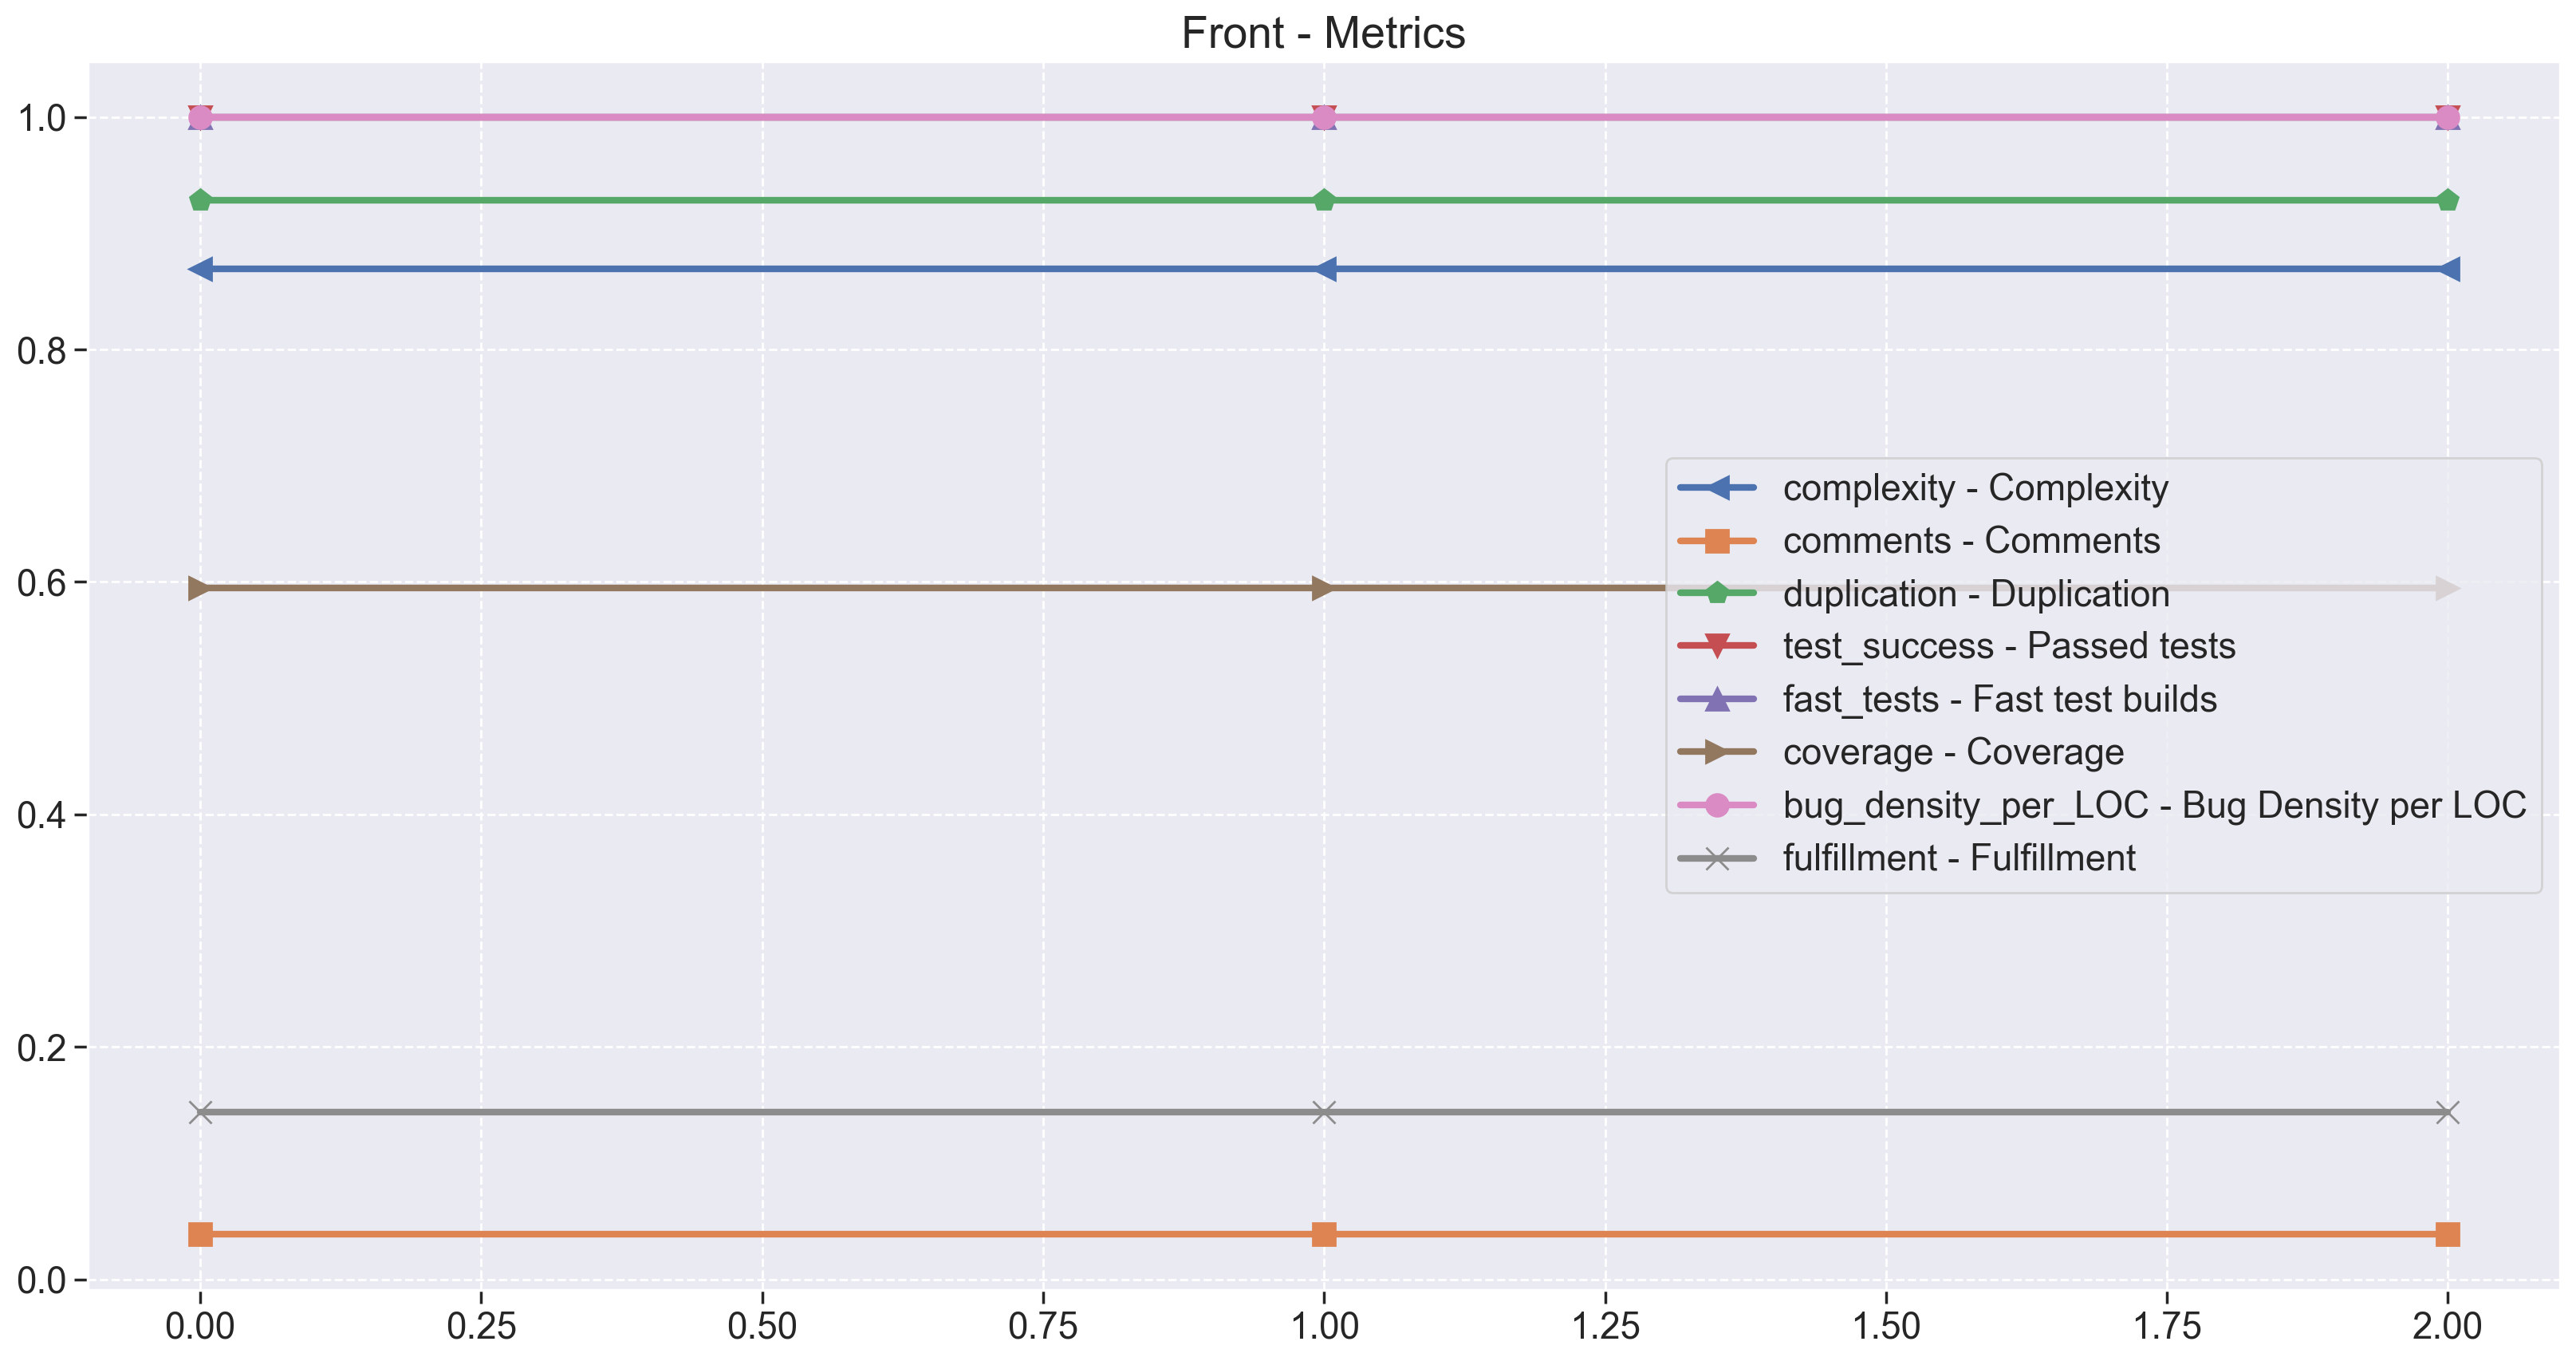

In [84]:
for name, data in metrics.items():
    fig = plt.figure(figsize=(20, 10))

    plt.plot(data['complexity'], linewidth=3, marker='<', markersize=10, label="complexity - Complexity")
    plt.plot(data['comments'], linewidth=3, marker='s', markersize=10, label="comments - Comments")
    plt.plot(data['duplication'], linewidth=3, marker='p', markersize=10, label="duplication - Duplication")
    plt.plot(data['test_success'], linewidth=3, marker='v', markersize=10, label="test_success - Passed tests")
    plt.plot(data['fast_tests'], linewidth=3, marker='^', markersize=10, label="fast_tests - Fast test builds")
    plt.plot(data['coverage'], linewidth=3, marker='>', markersize=10, label="coverage - Coverage")
    plt.plot(data['bug_density_per_LOC'], linewidth=3, marker='o', markersize=10, label="bug_density_per_LOC - Bug Density per LOC")
    plt.plot(data['fulfillment'], linewidth=3, marker='x', markersize=10, label="fulfillment - Fulfillment")

    plt.title(f"{name} - Metrics", fontsize=20)
    plt.legend(loc='best')
    plt.show()

## Quality factor and aspect aggregation

In [ ]:
psc1 = 1
psc2 = 1
pc1 = 0.5
pc2 = 0.5
pm1 = 0.33
pm2 = 0.33
pm3 = 0.33
pm4 = 0.25
pm5 = 0.25
pm6 = 0.5


# Here you will need to create the code_quality and testing_status metrics for each repository.

for name, data in metrics.items():
    data['code_quality'] = ((data['complexity']*pm1) + (data['comments']*pm2) + (data['duplication']*pm3)) * psc1       # Como deve funcionar essa inserção ?
    data['testing_status'] = ((data['test_success']*pm4) + (data['fast_tests']*pm5) + (data['coverage']*pm6)) * psc2

### Code Quality visualization

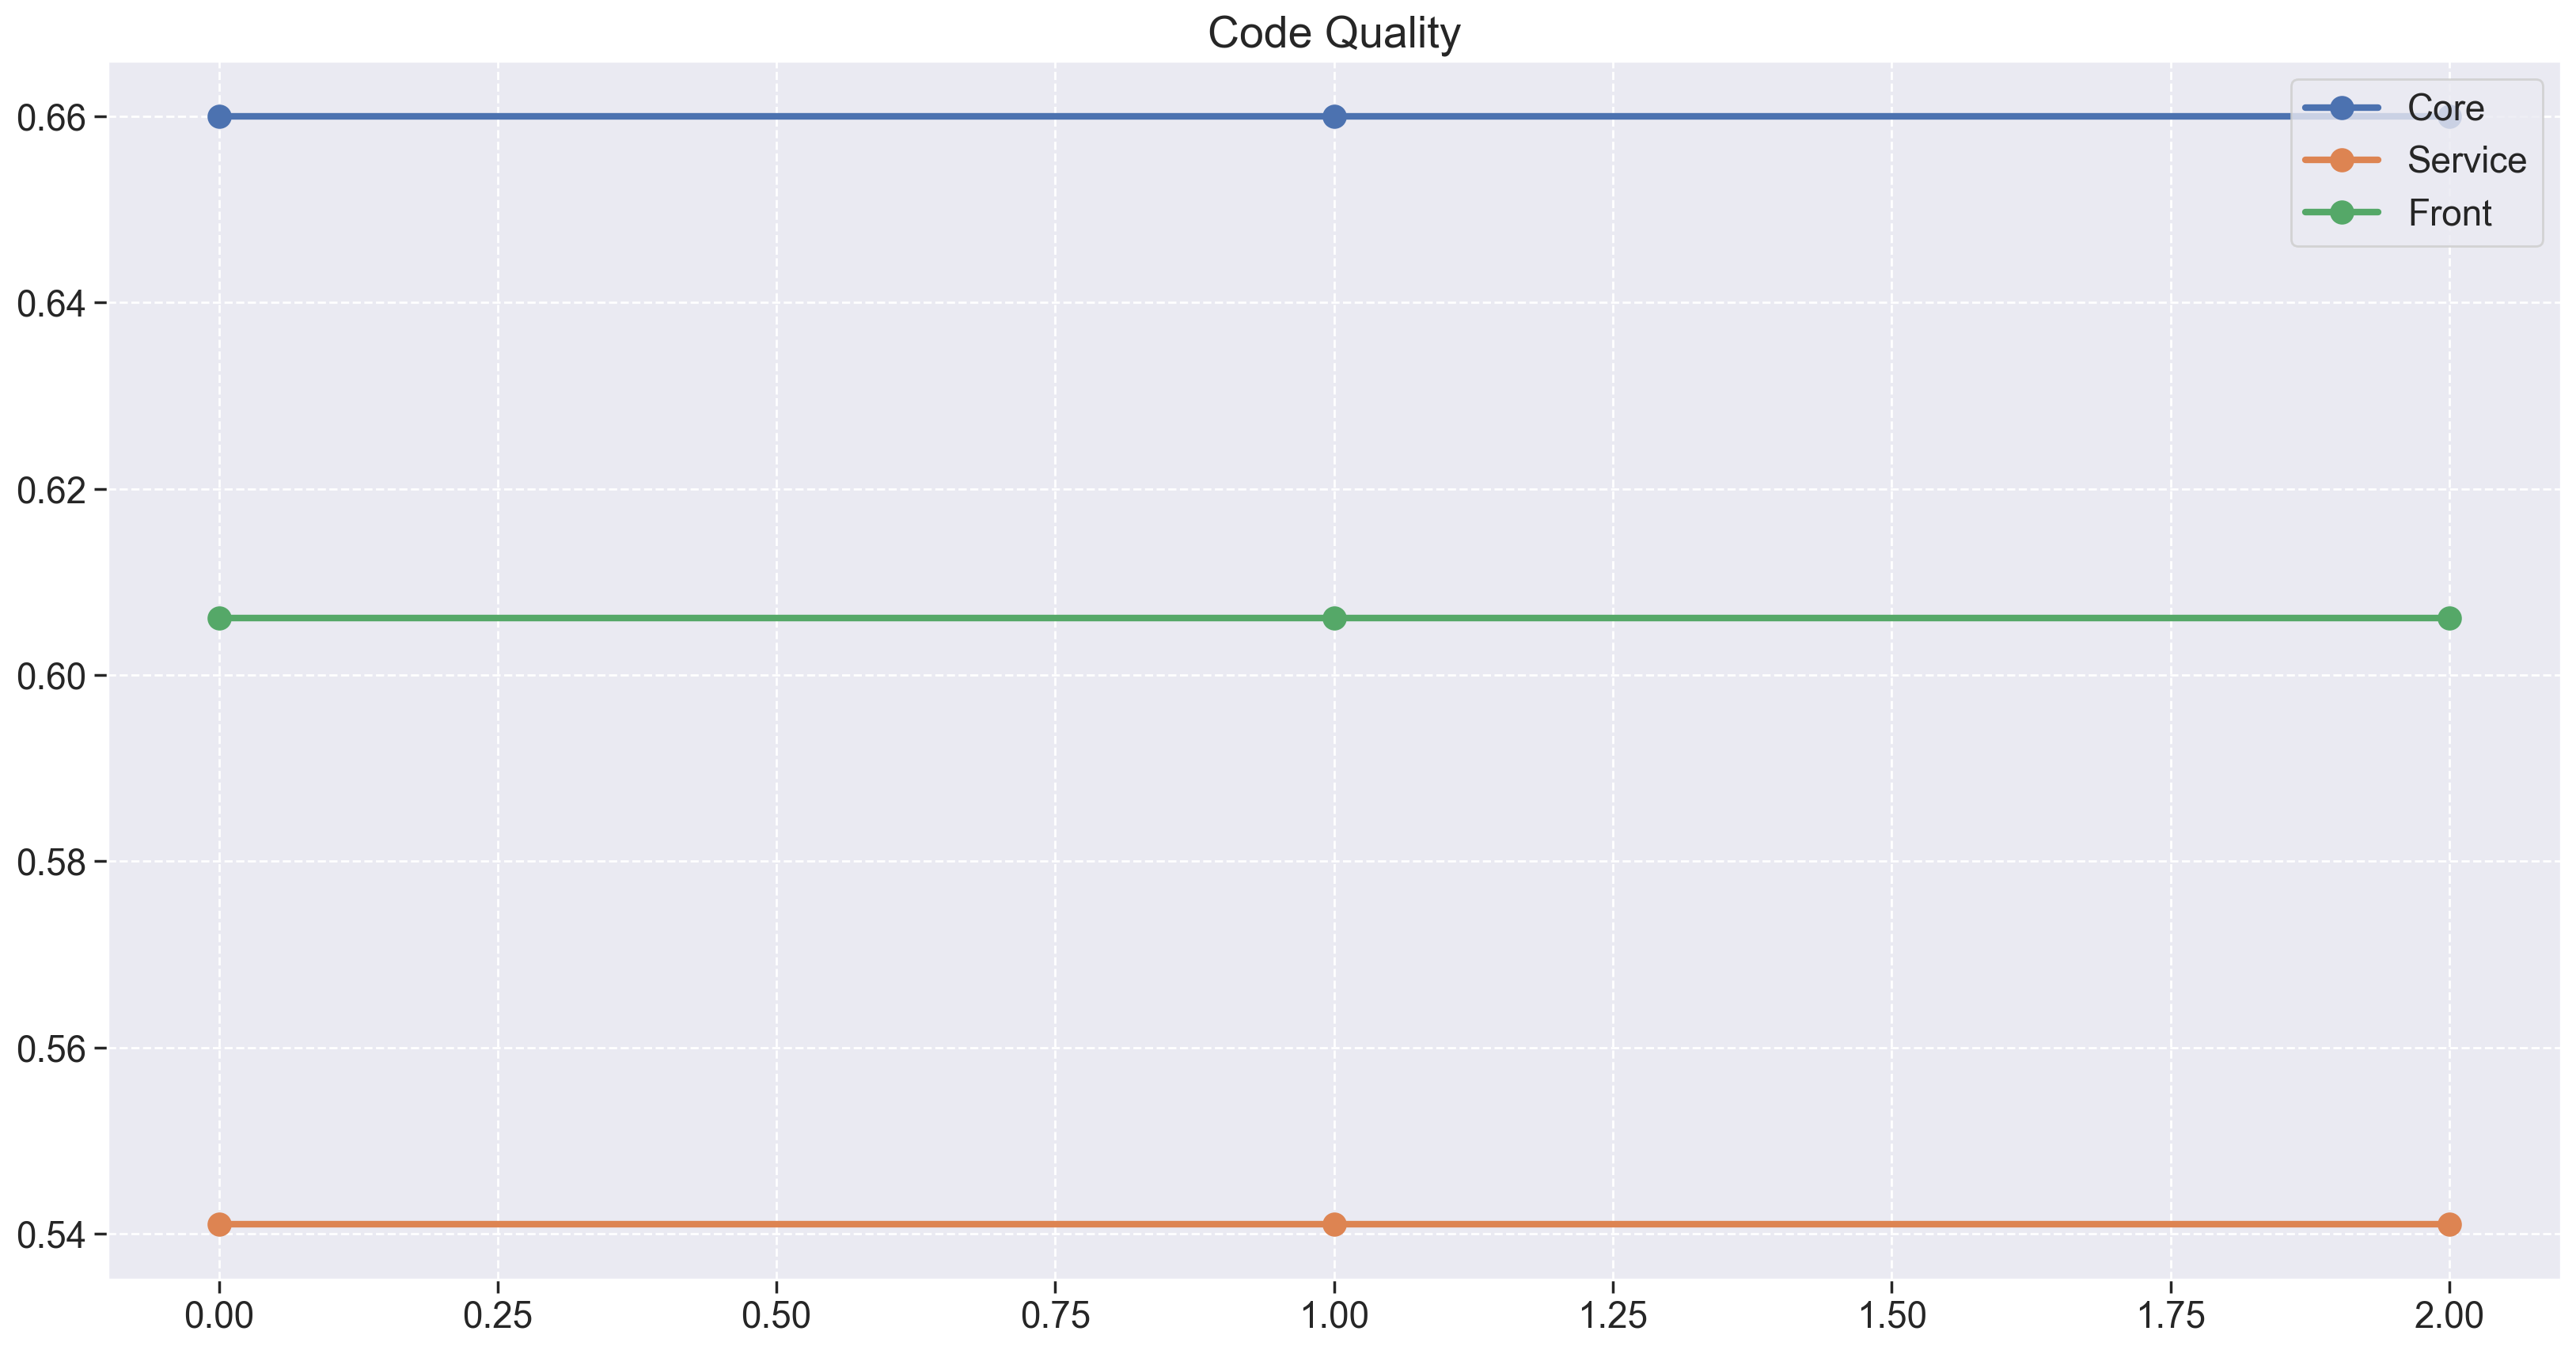

In [86]:
fig = plt.figure(figsize=(20, 10))

for name, data in metrics.items():
    plt.plot(data['code_quality'], linewidth=3, marker='o', markersize=10, label=name)

plt.title("Code Quality", fontsize=20)
plt.legend(loc='best')
plt.show()

### Testing Status visualization

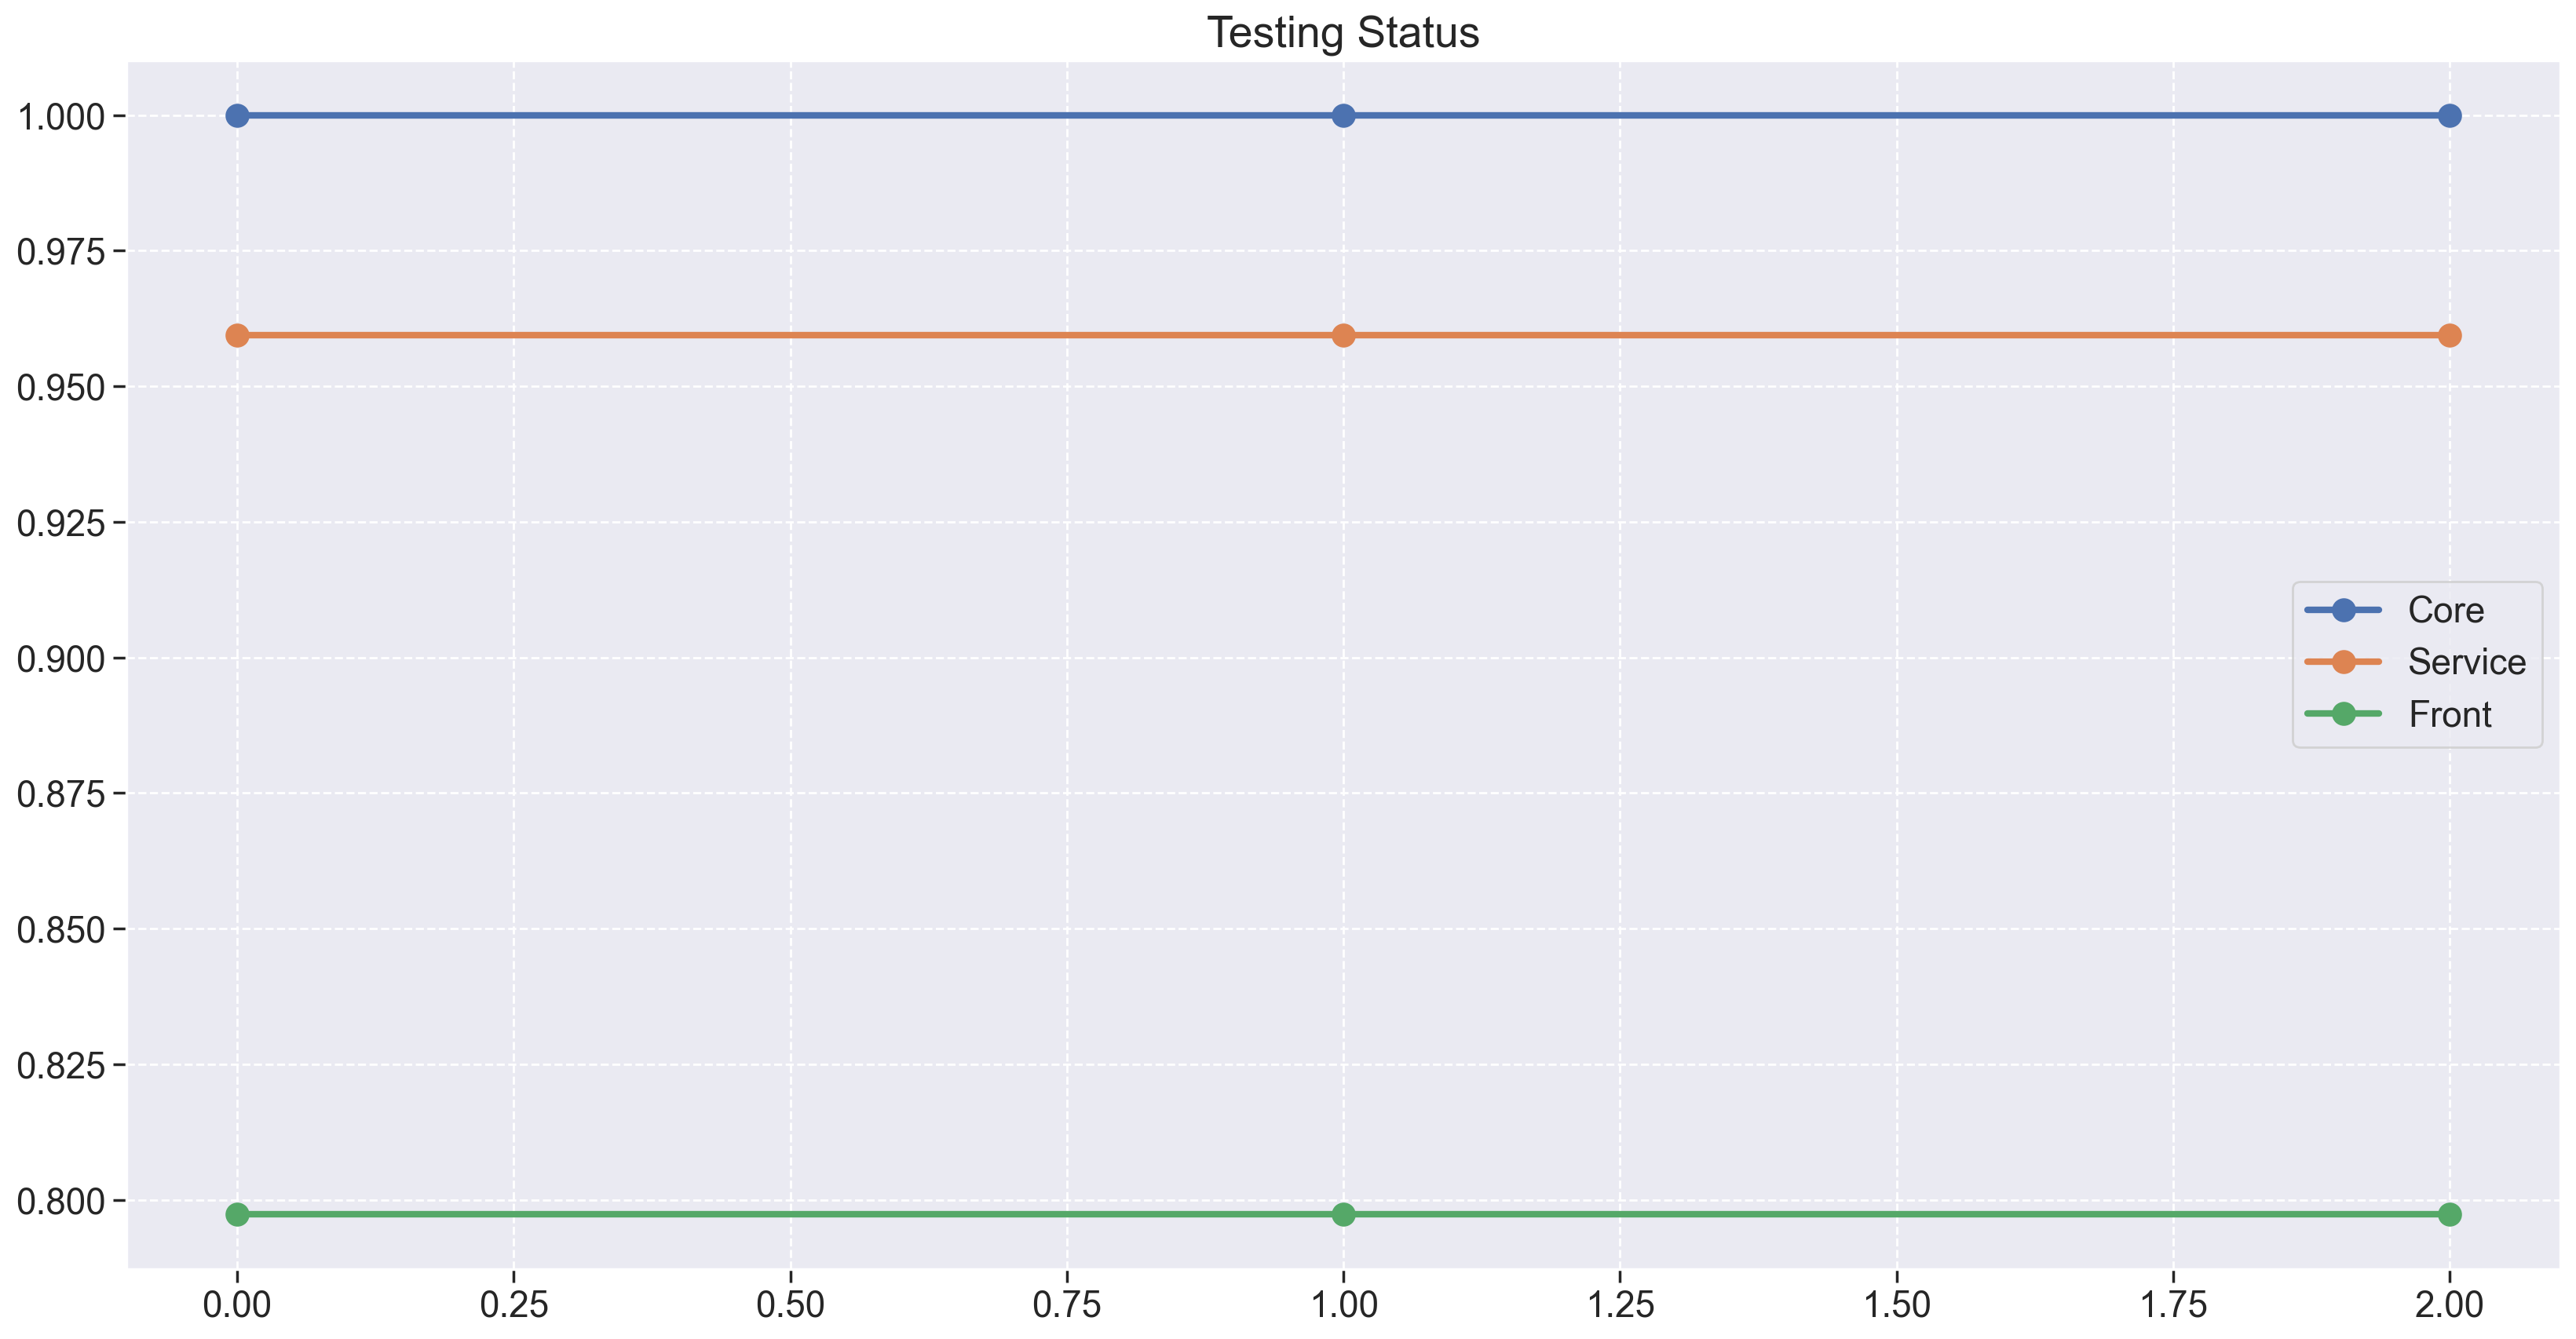

In [87]:
fig = plt.figure(figsize=(20, 10))

for name, data in metrics.items():
    plt.plot(data['testing_status'], linewidth=3, marker='o', markersize=10, label=name)

plt.title("Testing Status", fontsize=20)
plt.legend(loc='best')
plt.show()

### Aggregations

In [ ]:
for name, data in metrics.items():
    data['Maintainability'] = data['code_quality'] * pc1
    data['Reliability'] = data['testing_status'] * pc2              # Deve haver uma composição ?
    data['total'] = data['Maintainability'] + data['Reliability']

## Repositories analysis

In [89]:
def get_characteristc_stats(repo_series):
    return {
        'mean': repo_series.mean(),
        'mode': repo_series.mode(),
        'median': repo_series.median(),
        'std': repo_series.std(),
        'var': repo_series.var(),
        'min': repo_series.min(),
        'max': repo_series.max()
    }

In [90]:
def analysis(metrics, name):
    maintainability_stats = pd.DataFrame(get_characteristc_stats(metrics["Maintainability"]),
                                     columns=['mean', 'mode', 'median', 'std', 'var', 'min', 'max'])

    reliability_stats = pd.DataFrame(get_characteristc_stats(metrics["Reliability"]),
                                 columns=['mean', 'mode', 'median', 'std', 'var', 'min', 'max'])


    print("Maintainability Stats")
    print(maintainability_stats.to_string(index=False))

    print("Reliability Stats")
    print(reliability_stats.to_string(index=False))

    fig = plt.figure(figsize=(20, 10))

    plt.plot(metrics['Maintainability'], linewidth=3, marker='o', markersize=10, label="Maintainability")
    plt.plot(metrics['Reliability'], linewidth=3, marker='*', markersize=10, label="Reliability")

    plt.ylim(0.1,1.1)
    plt.title(f'{name} - Maintainability and Reliability', fontsize=20)
    plt.legend(loc='best')
    plt.show()

    fig = plt.figure(figsize=(20, 10))

    plt.plot(metrics['total'], linewidth=3, marker='X', markersize=5)

    plt.ylim(0.1,1.1)
    plt.title(f'{name} - Total', fontsize=20)
    plt.show()

### Analysis loop in each repo

Core
Maintainability Stats
 mean  mode  median  std  var  min  max
 0.33  0.33    0.33  0.0  0.0 0.33 0.33
Reliability Stats
 mean  mode  median  std  var  min  max
  0.5   0.5     0.5  0.0  0.0  0.5  0.5


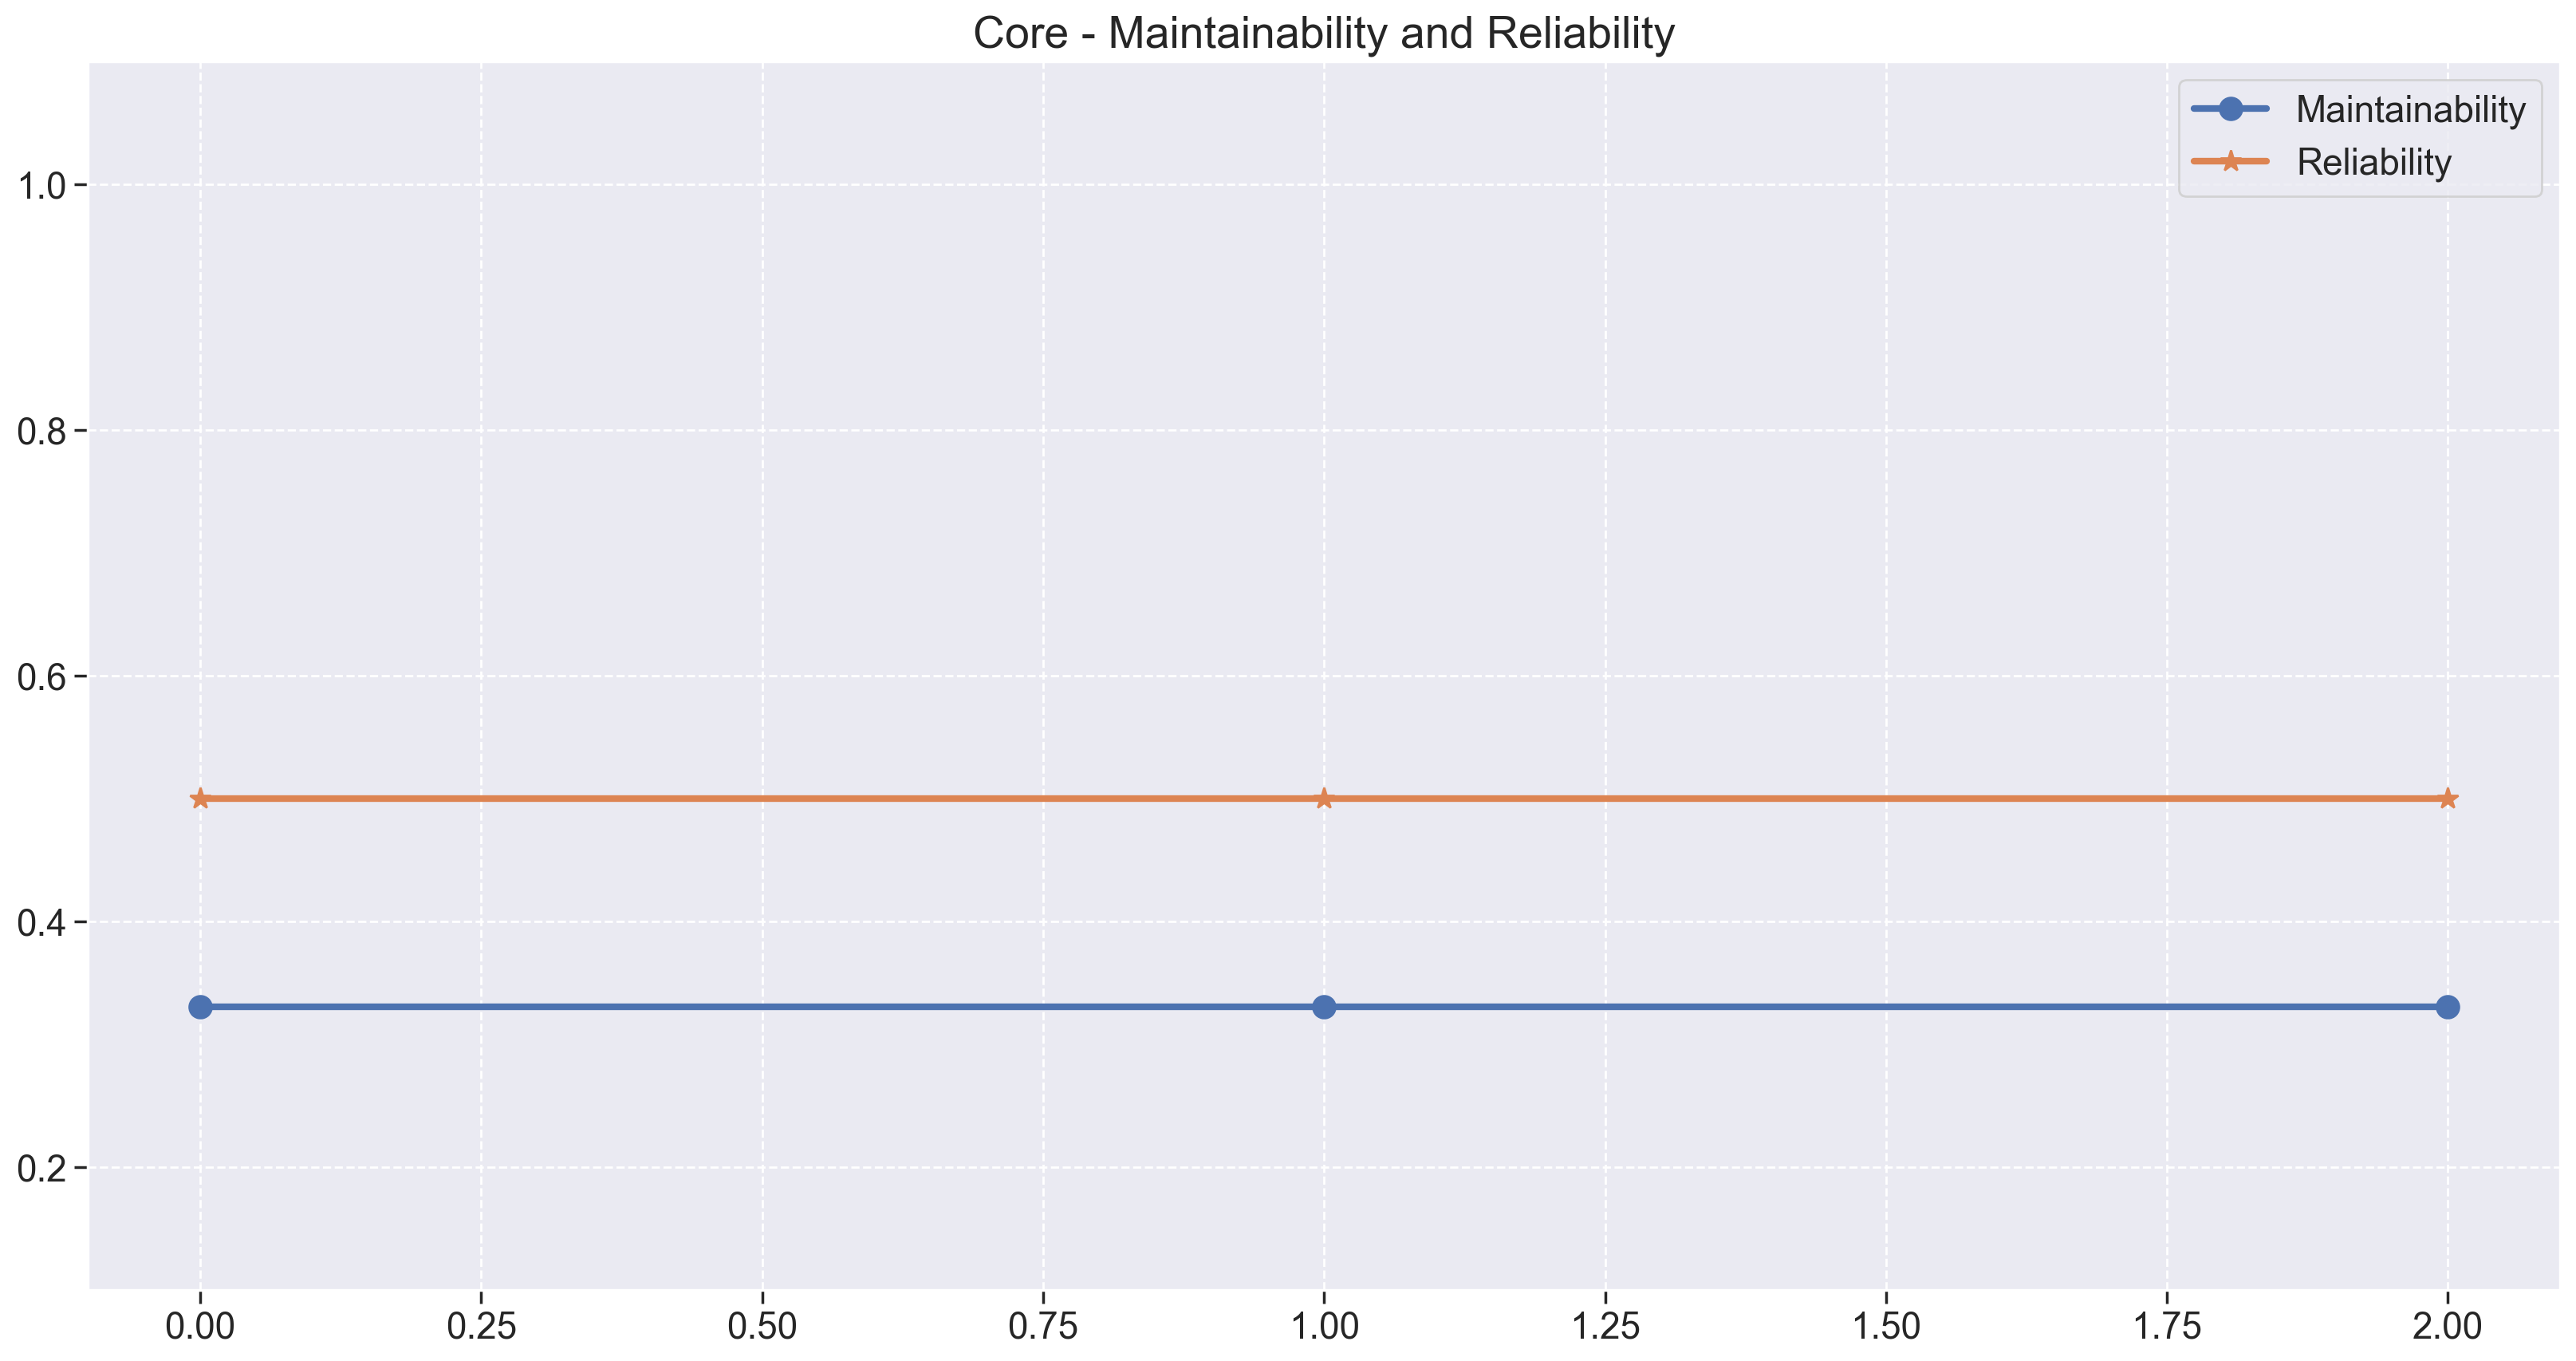

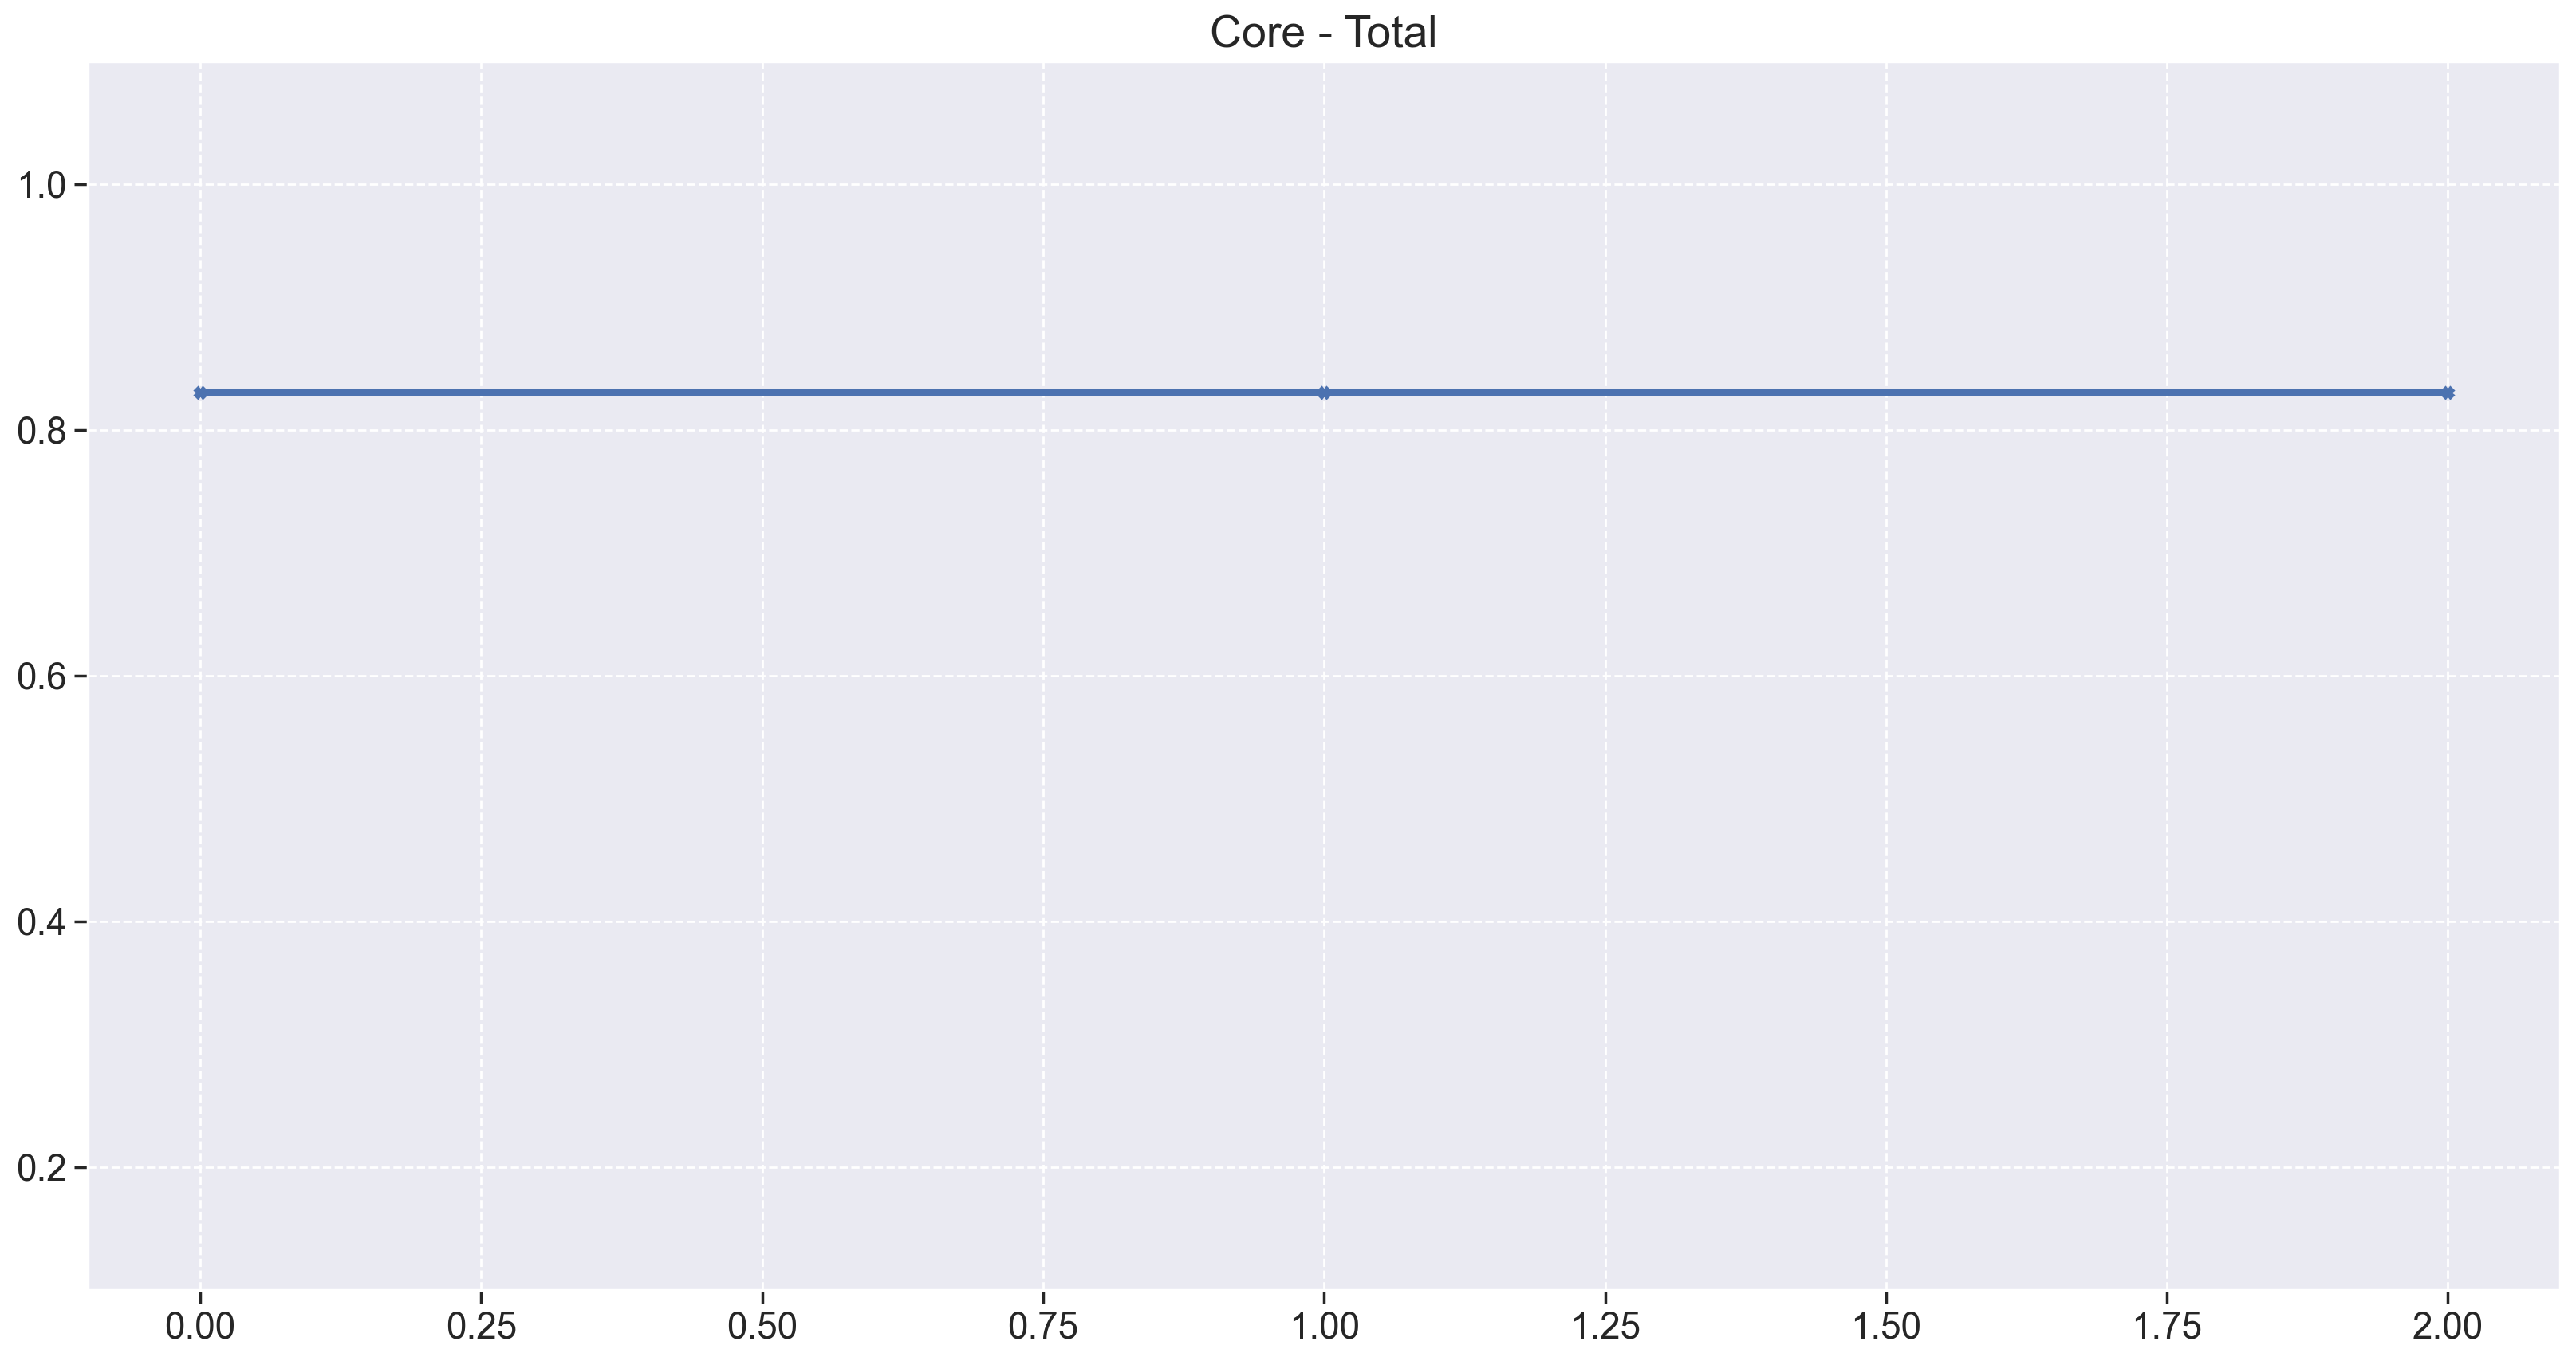

Service
Maintainability Stats
    mean     mode   median  std  var      min      max
0.270541 0.270541 0.270541  0.0  0.0 0.270541 0.270541
Reliability Stats
   mean    mode  median          std          var     min     max
0.47973 0.47973 0.47973 6.798700e-17 4.622232e-33 0.47973 0.47973


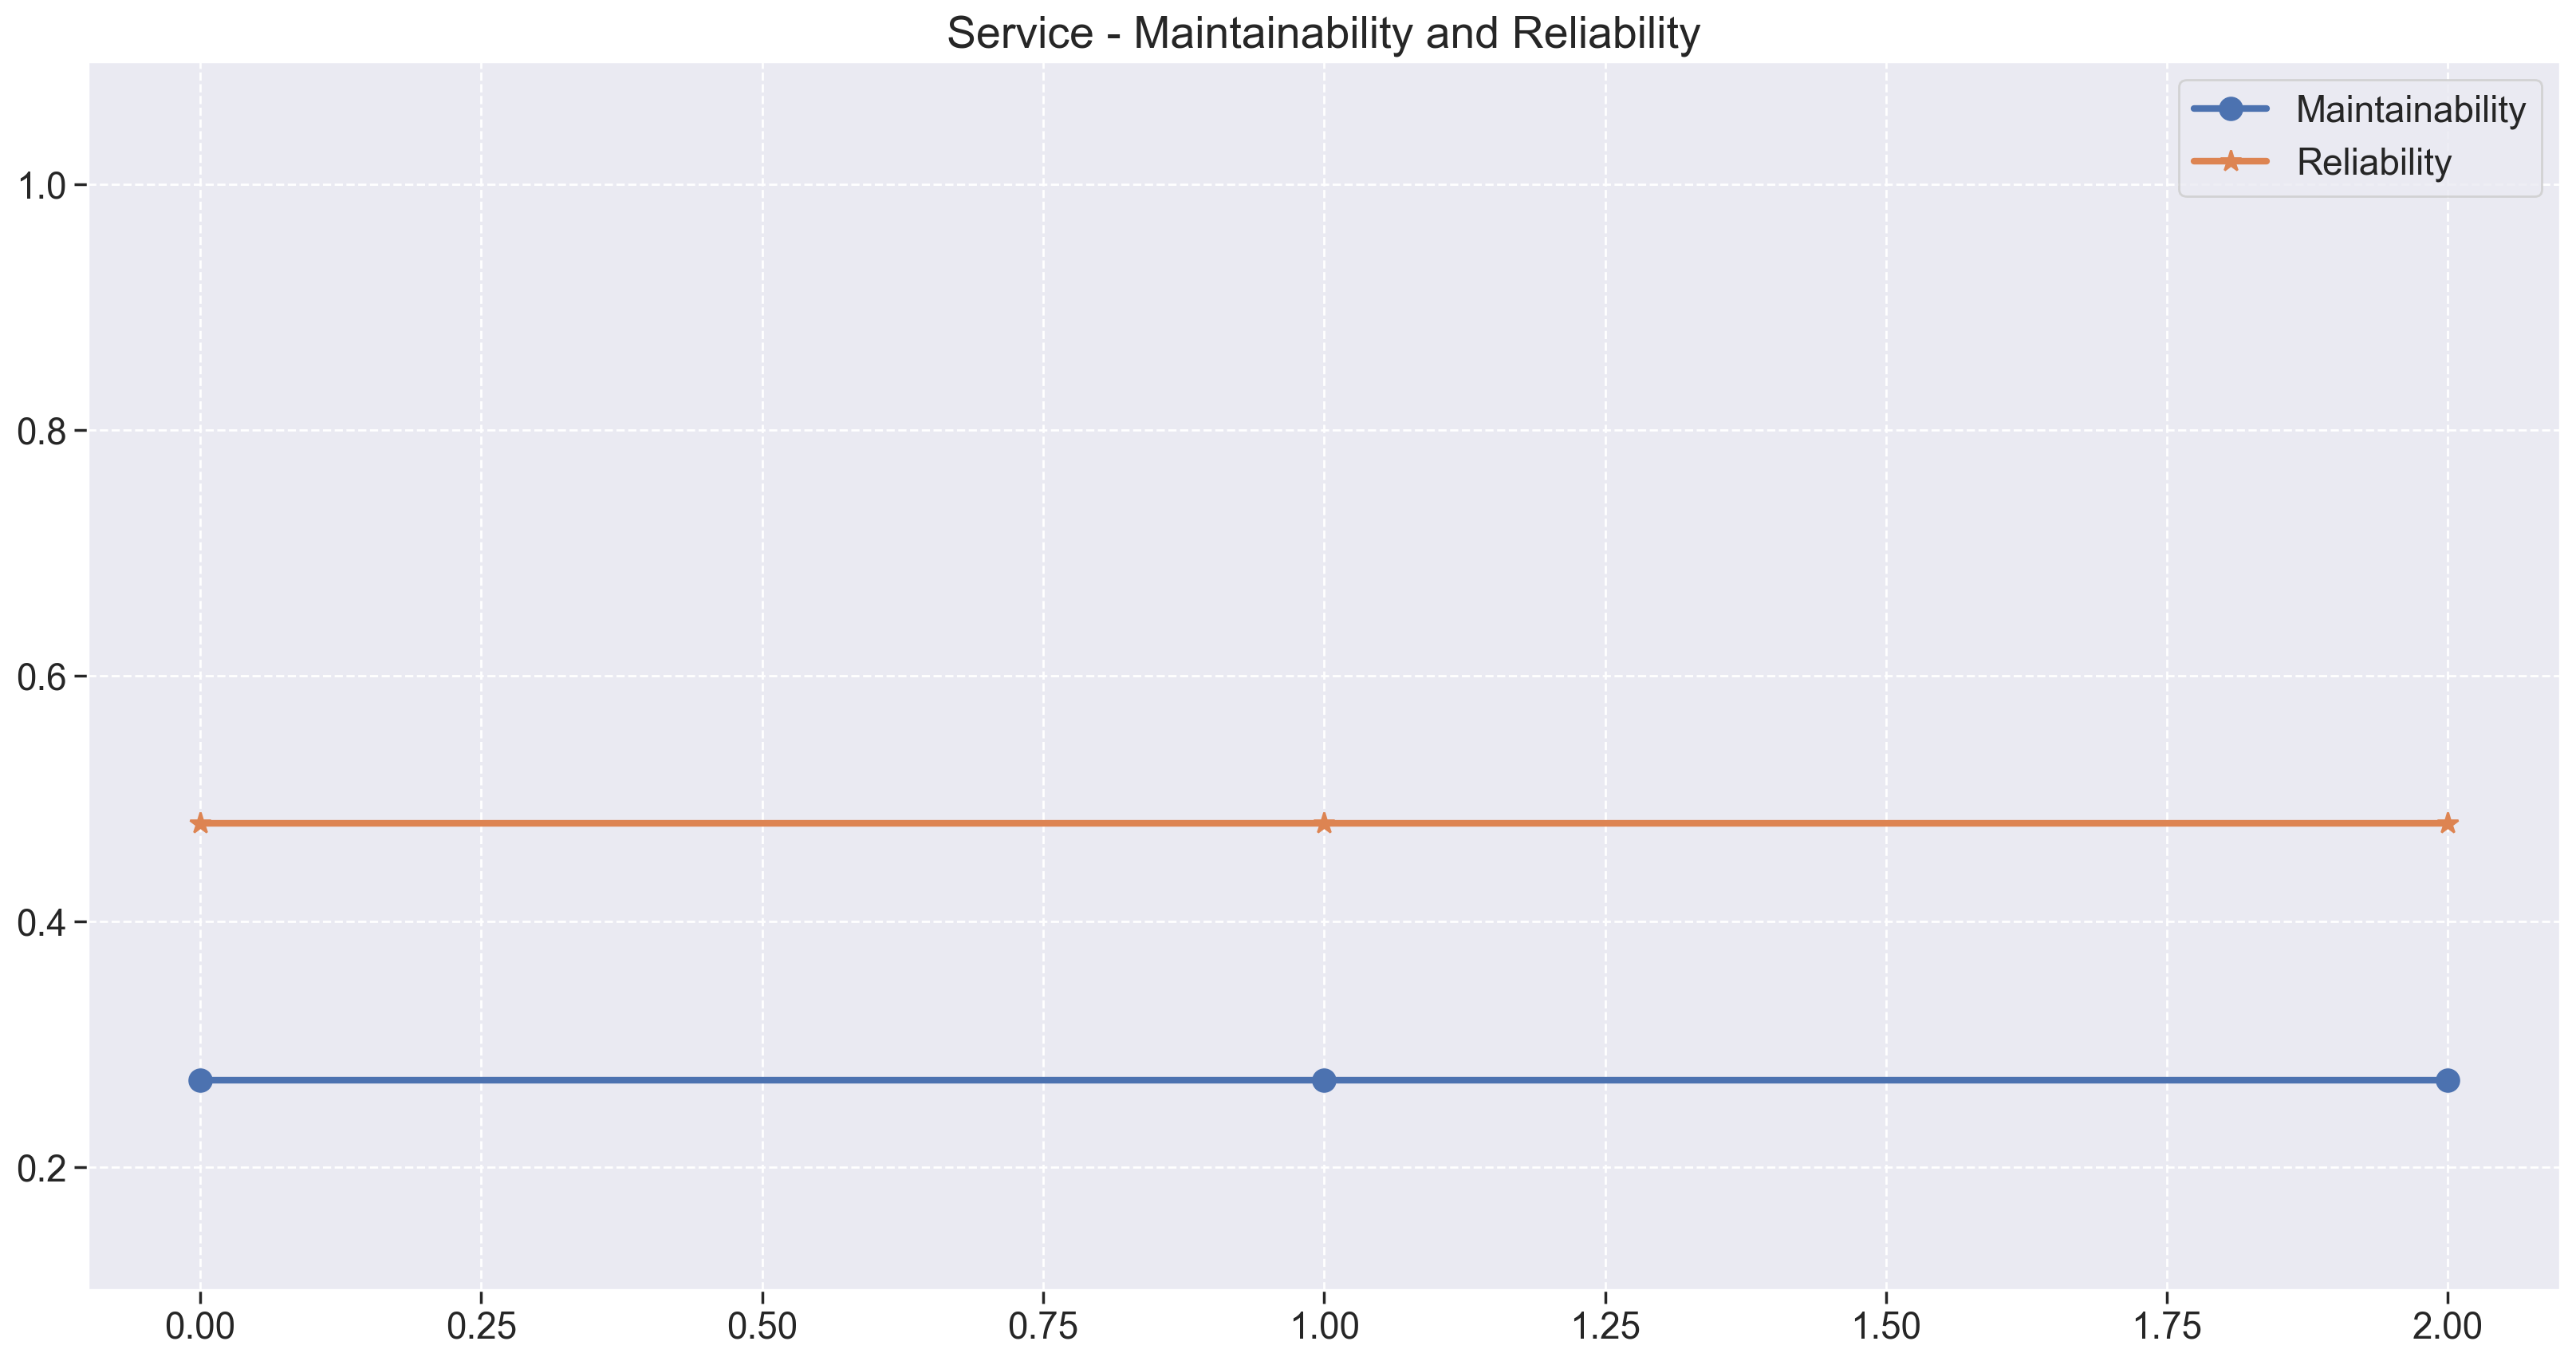

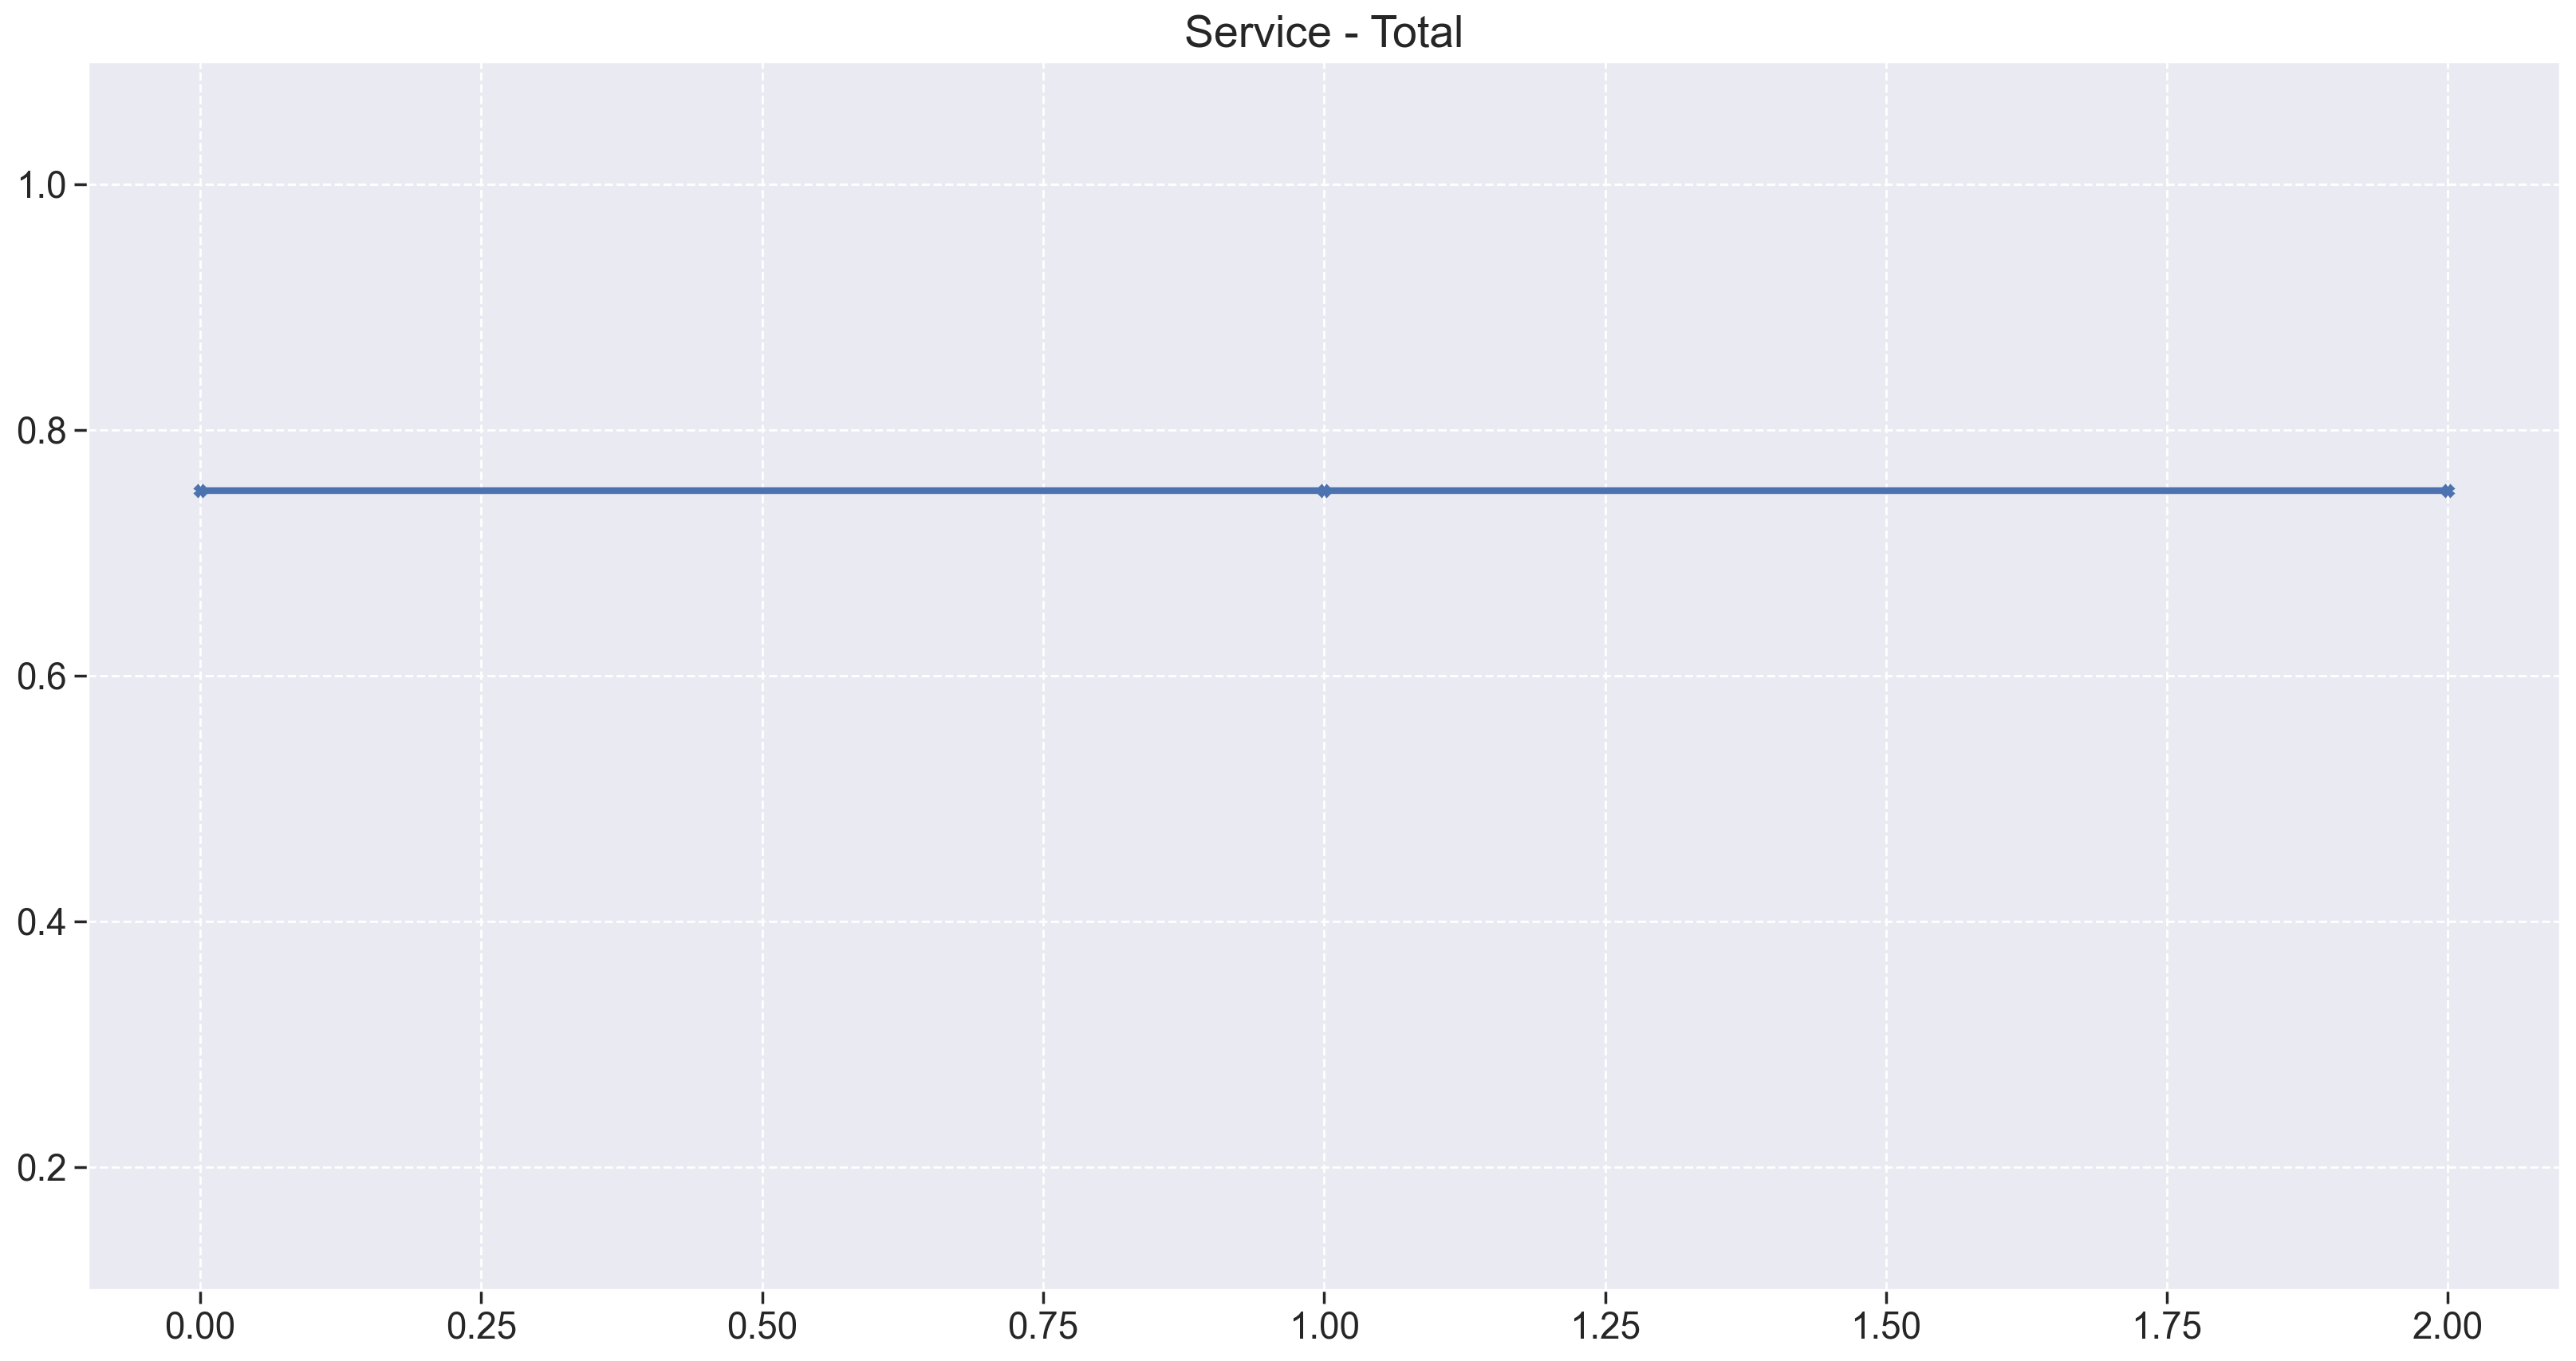

Front
Maintainability Stats
    mean     mode   median  std  var      min      max
0.303039 0.303039 0.303039  0.0  0.0 0.303039 0.303039
Reliability Stats
    mean     mode   median          std          var      min      max
0.398693 0.398693 0.398693 6.798700e-17 4.622232e-33 0.398693 0.398693


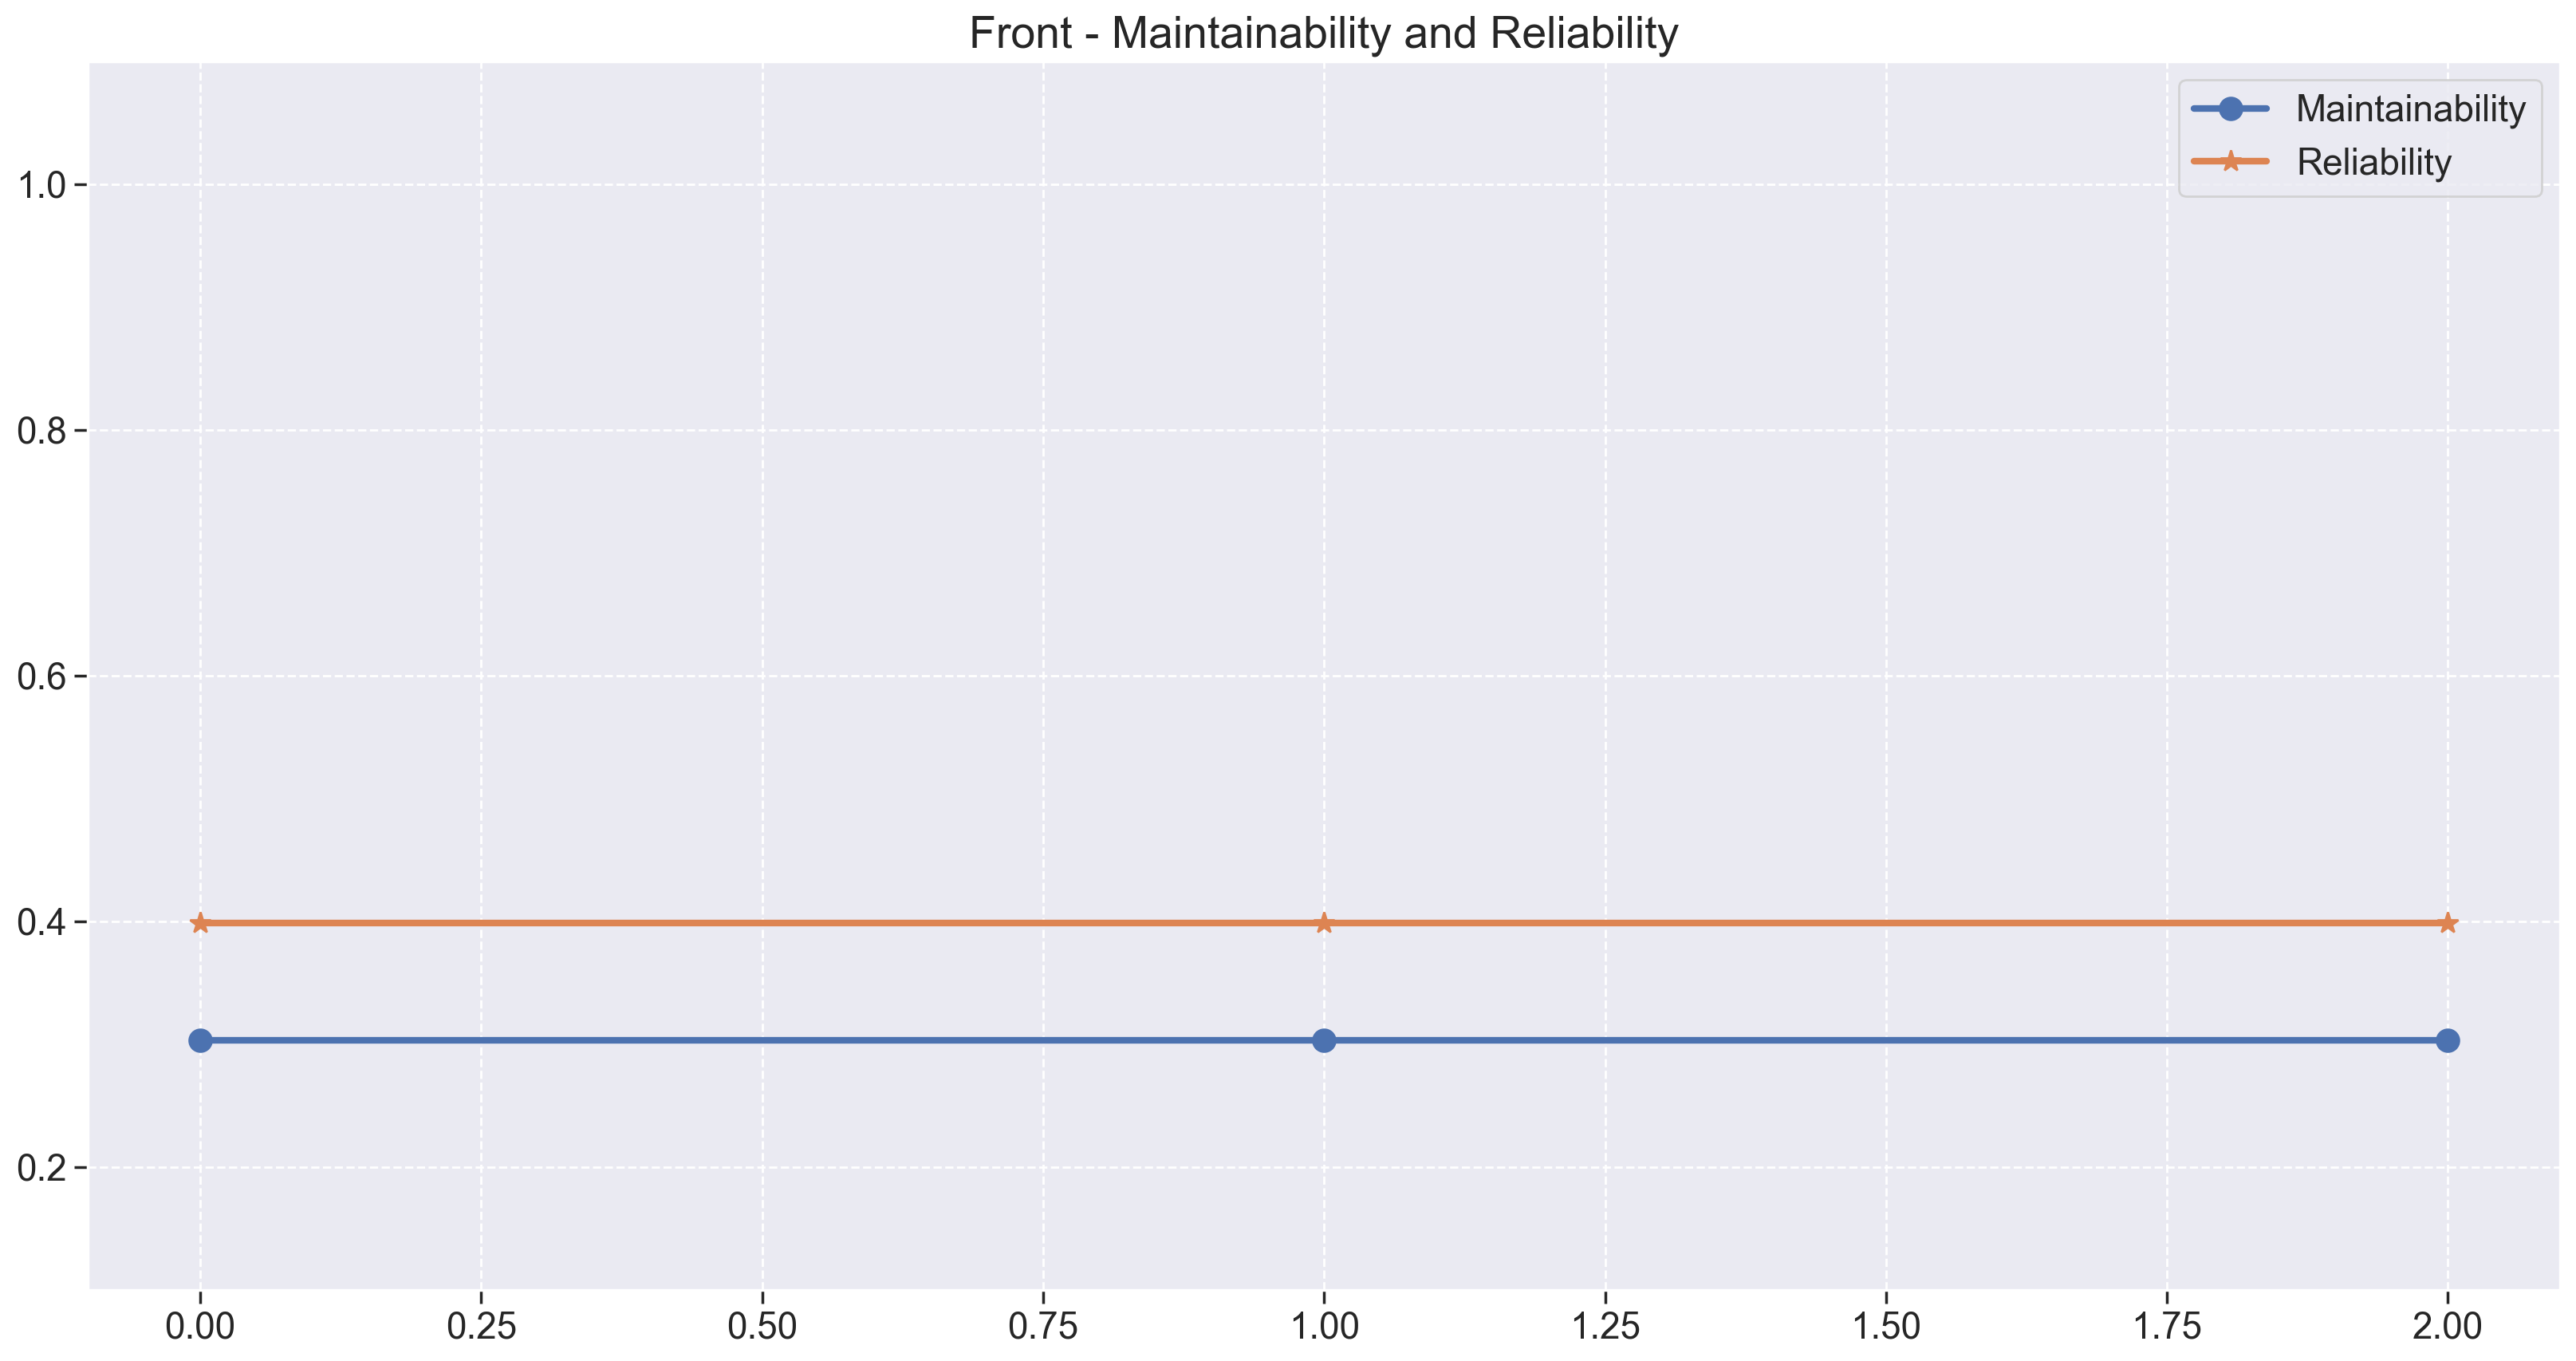

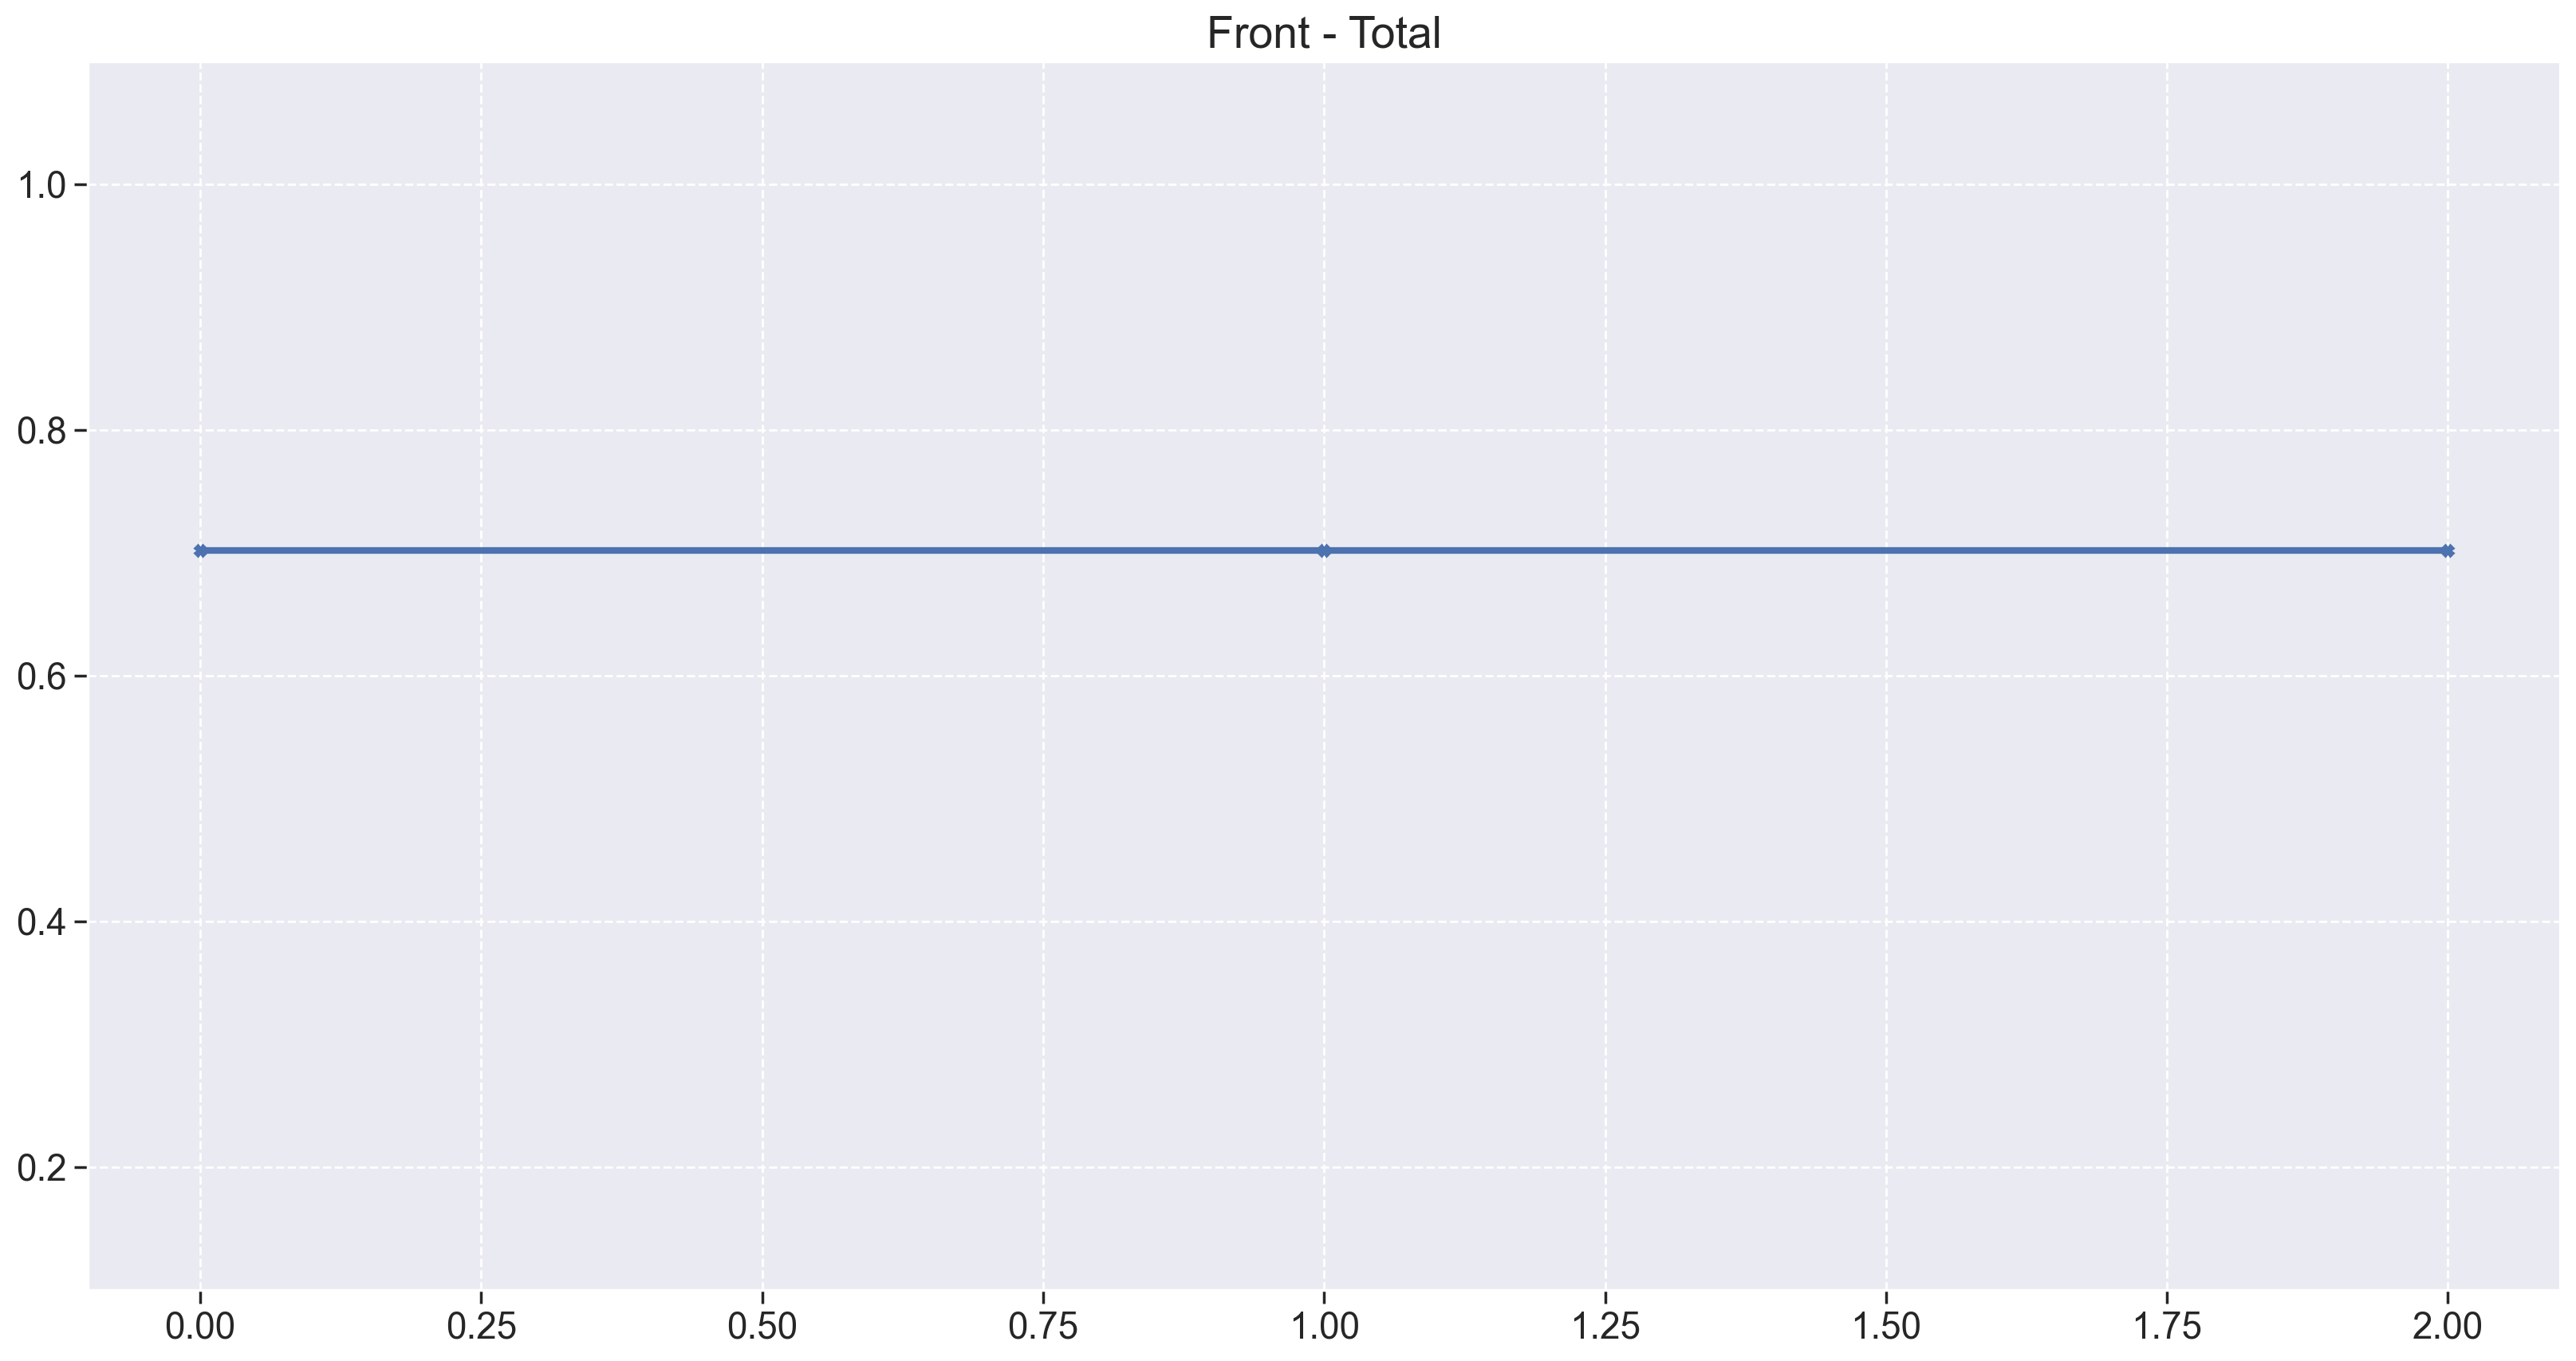

In [91]:
for name, data in metrics.items():
    print(name)
    analysis(data, name)

### Quality characteristic indicator

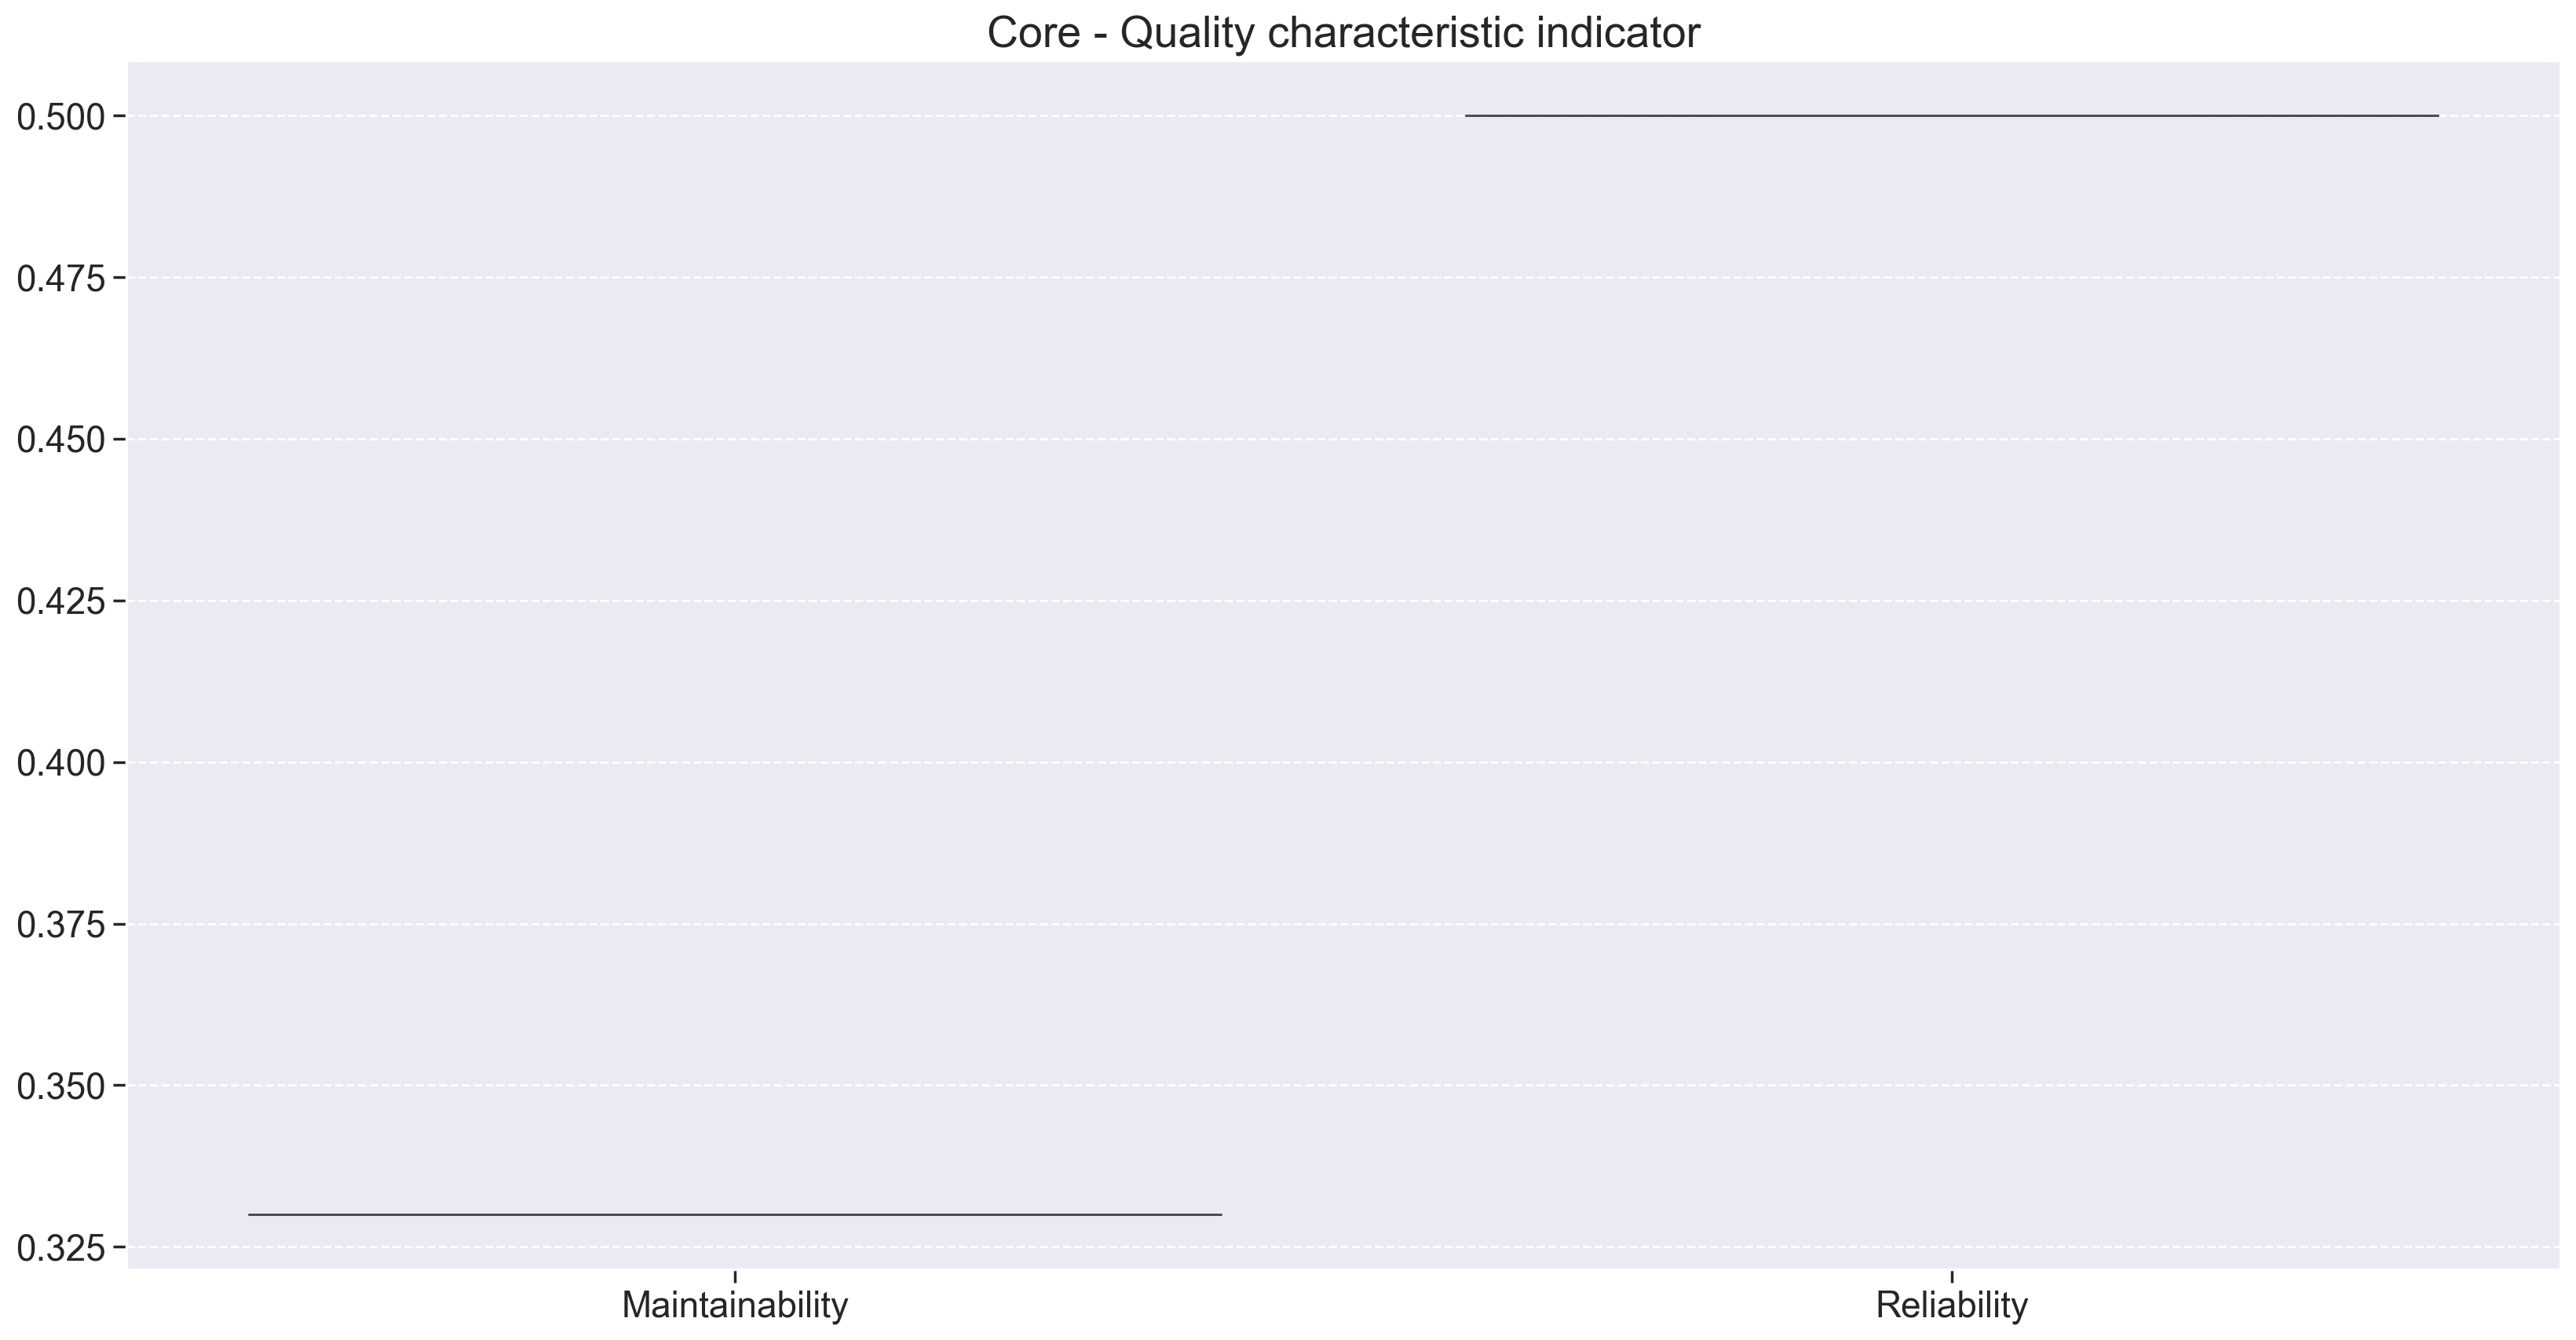

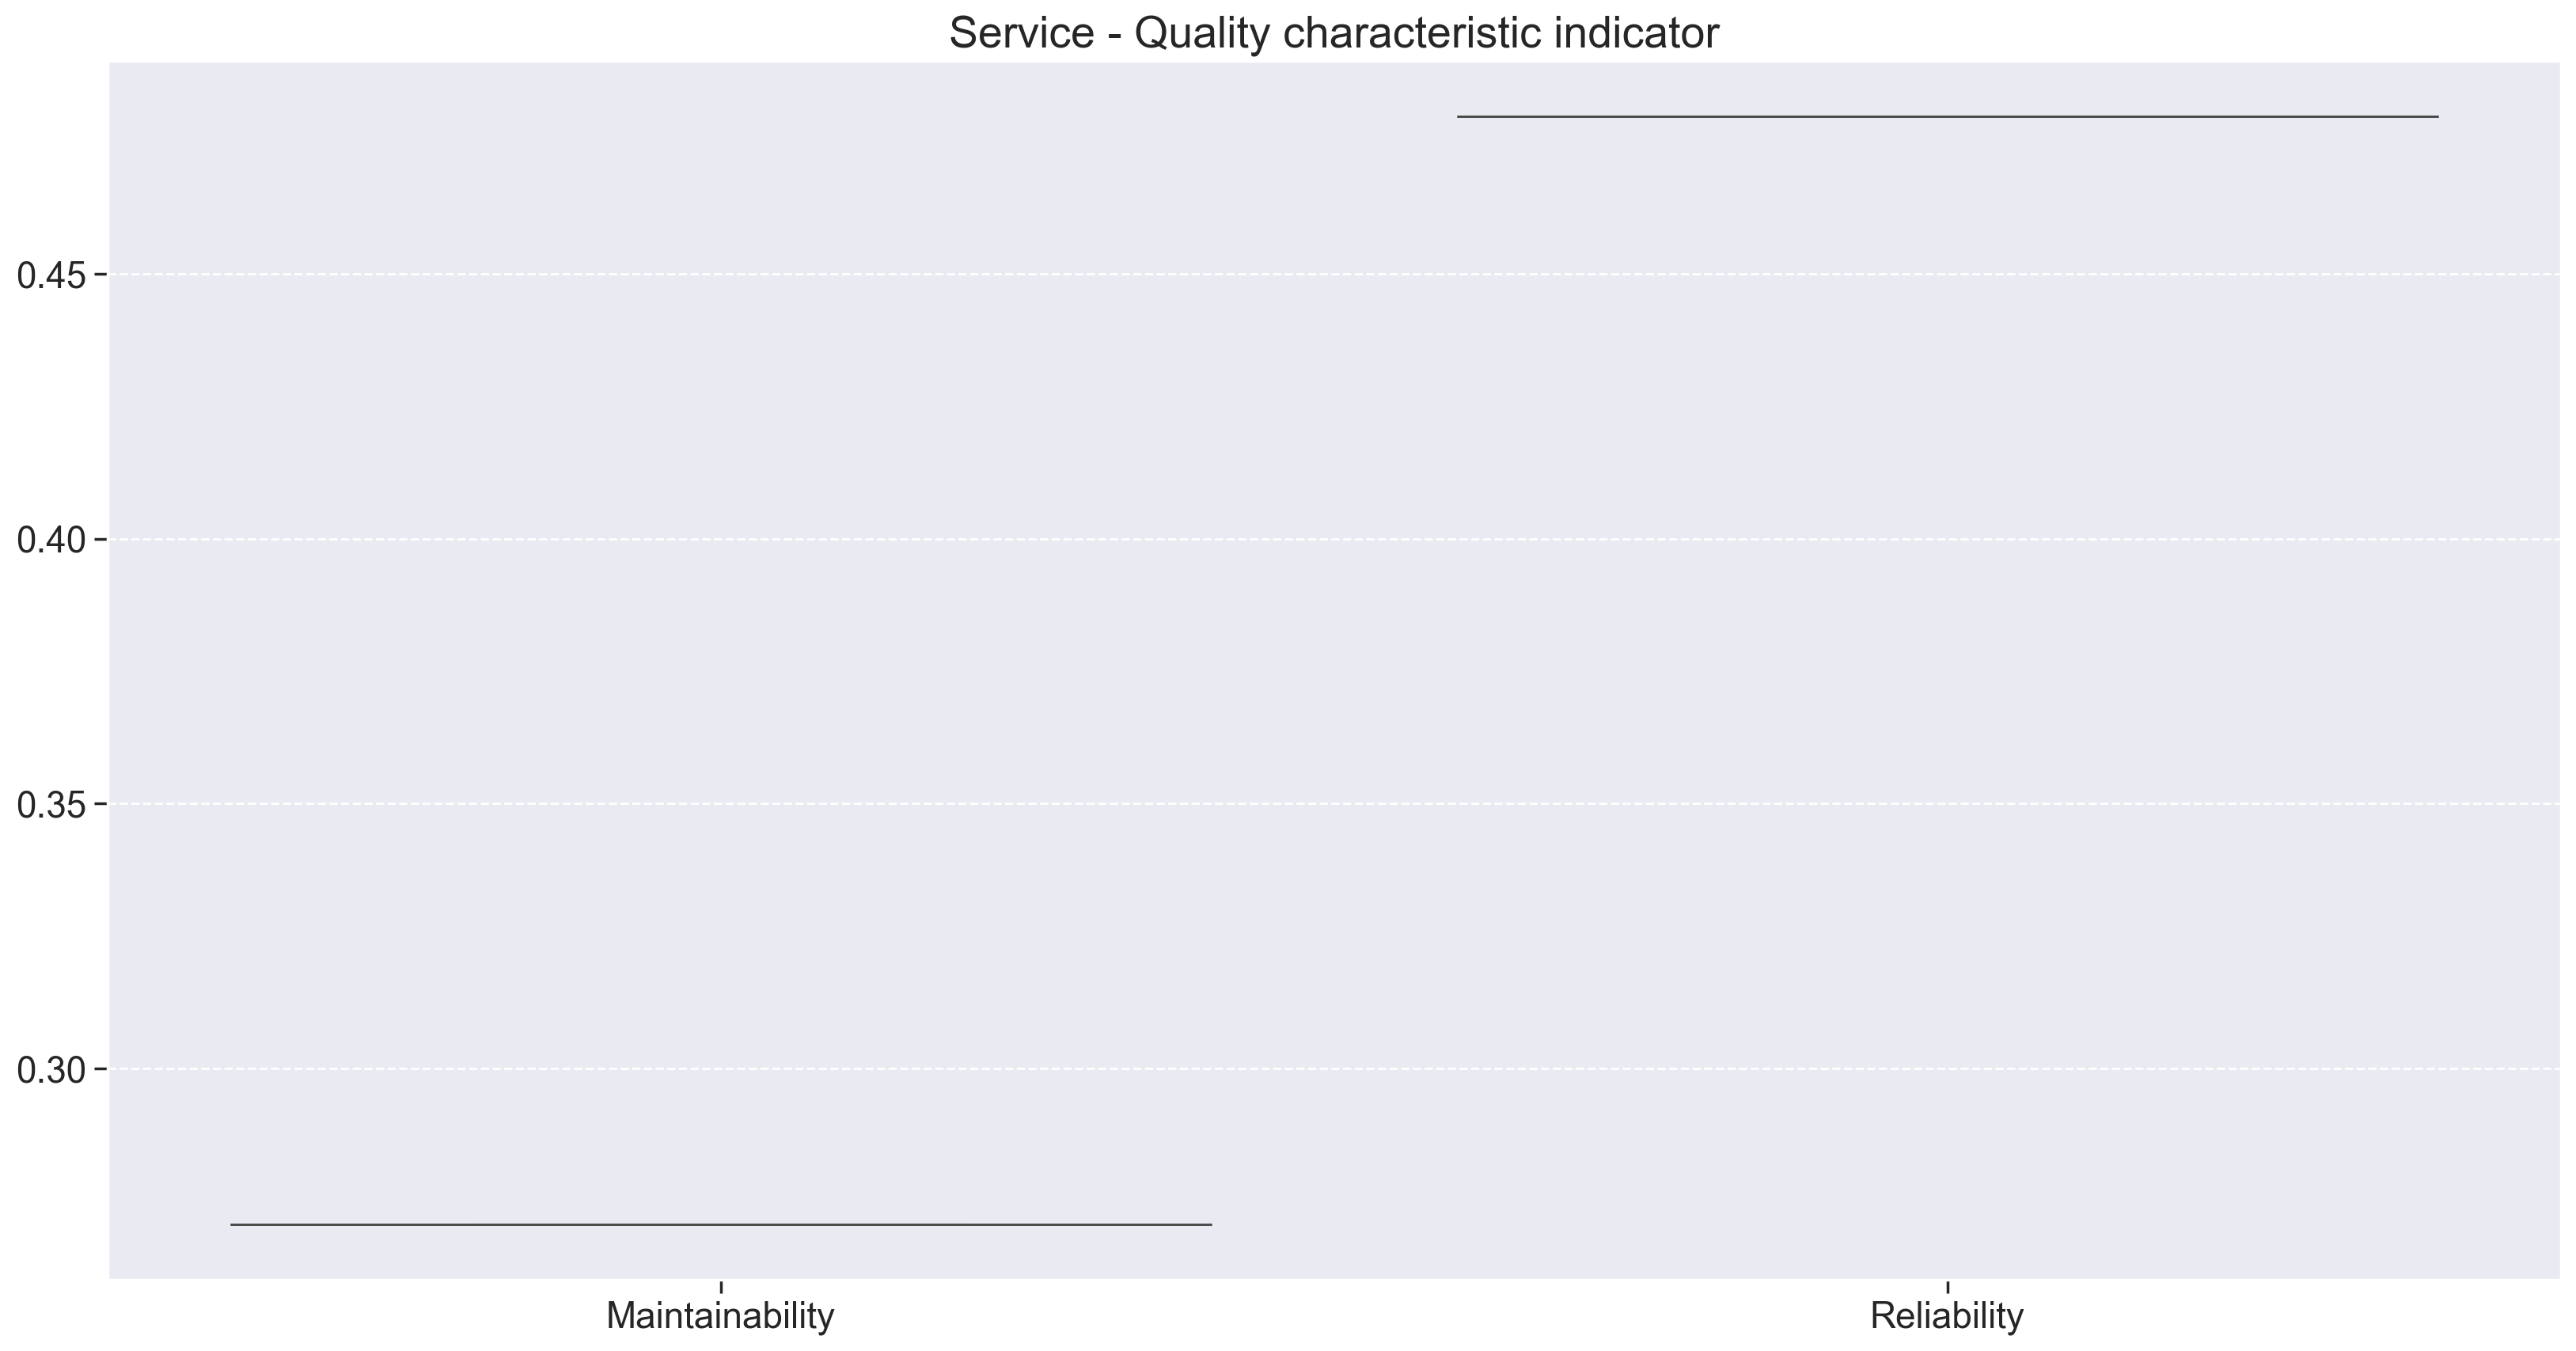

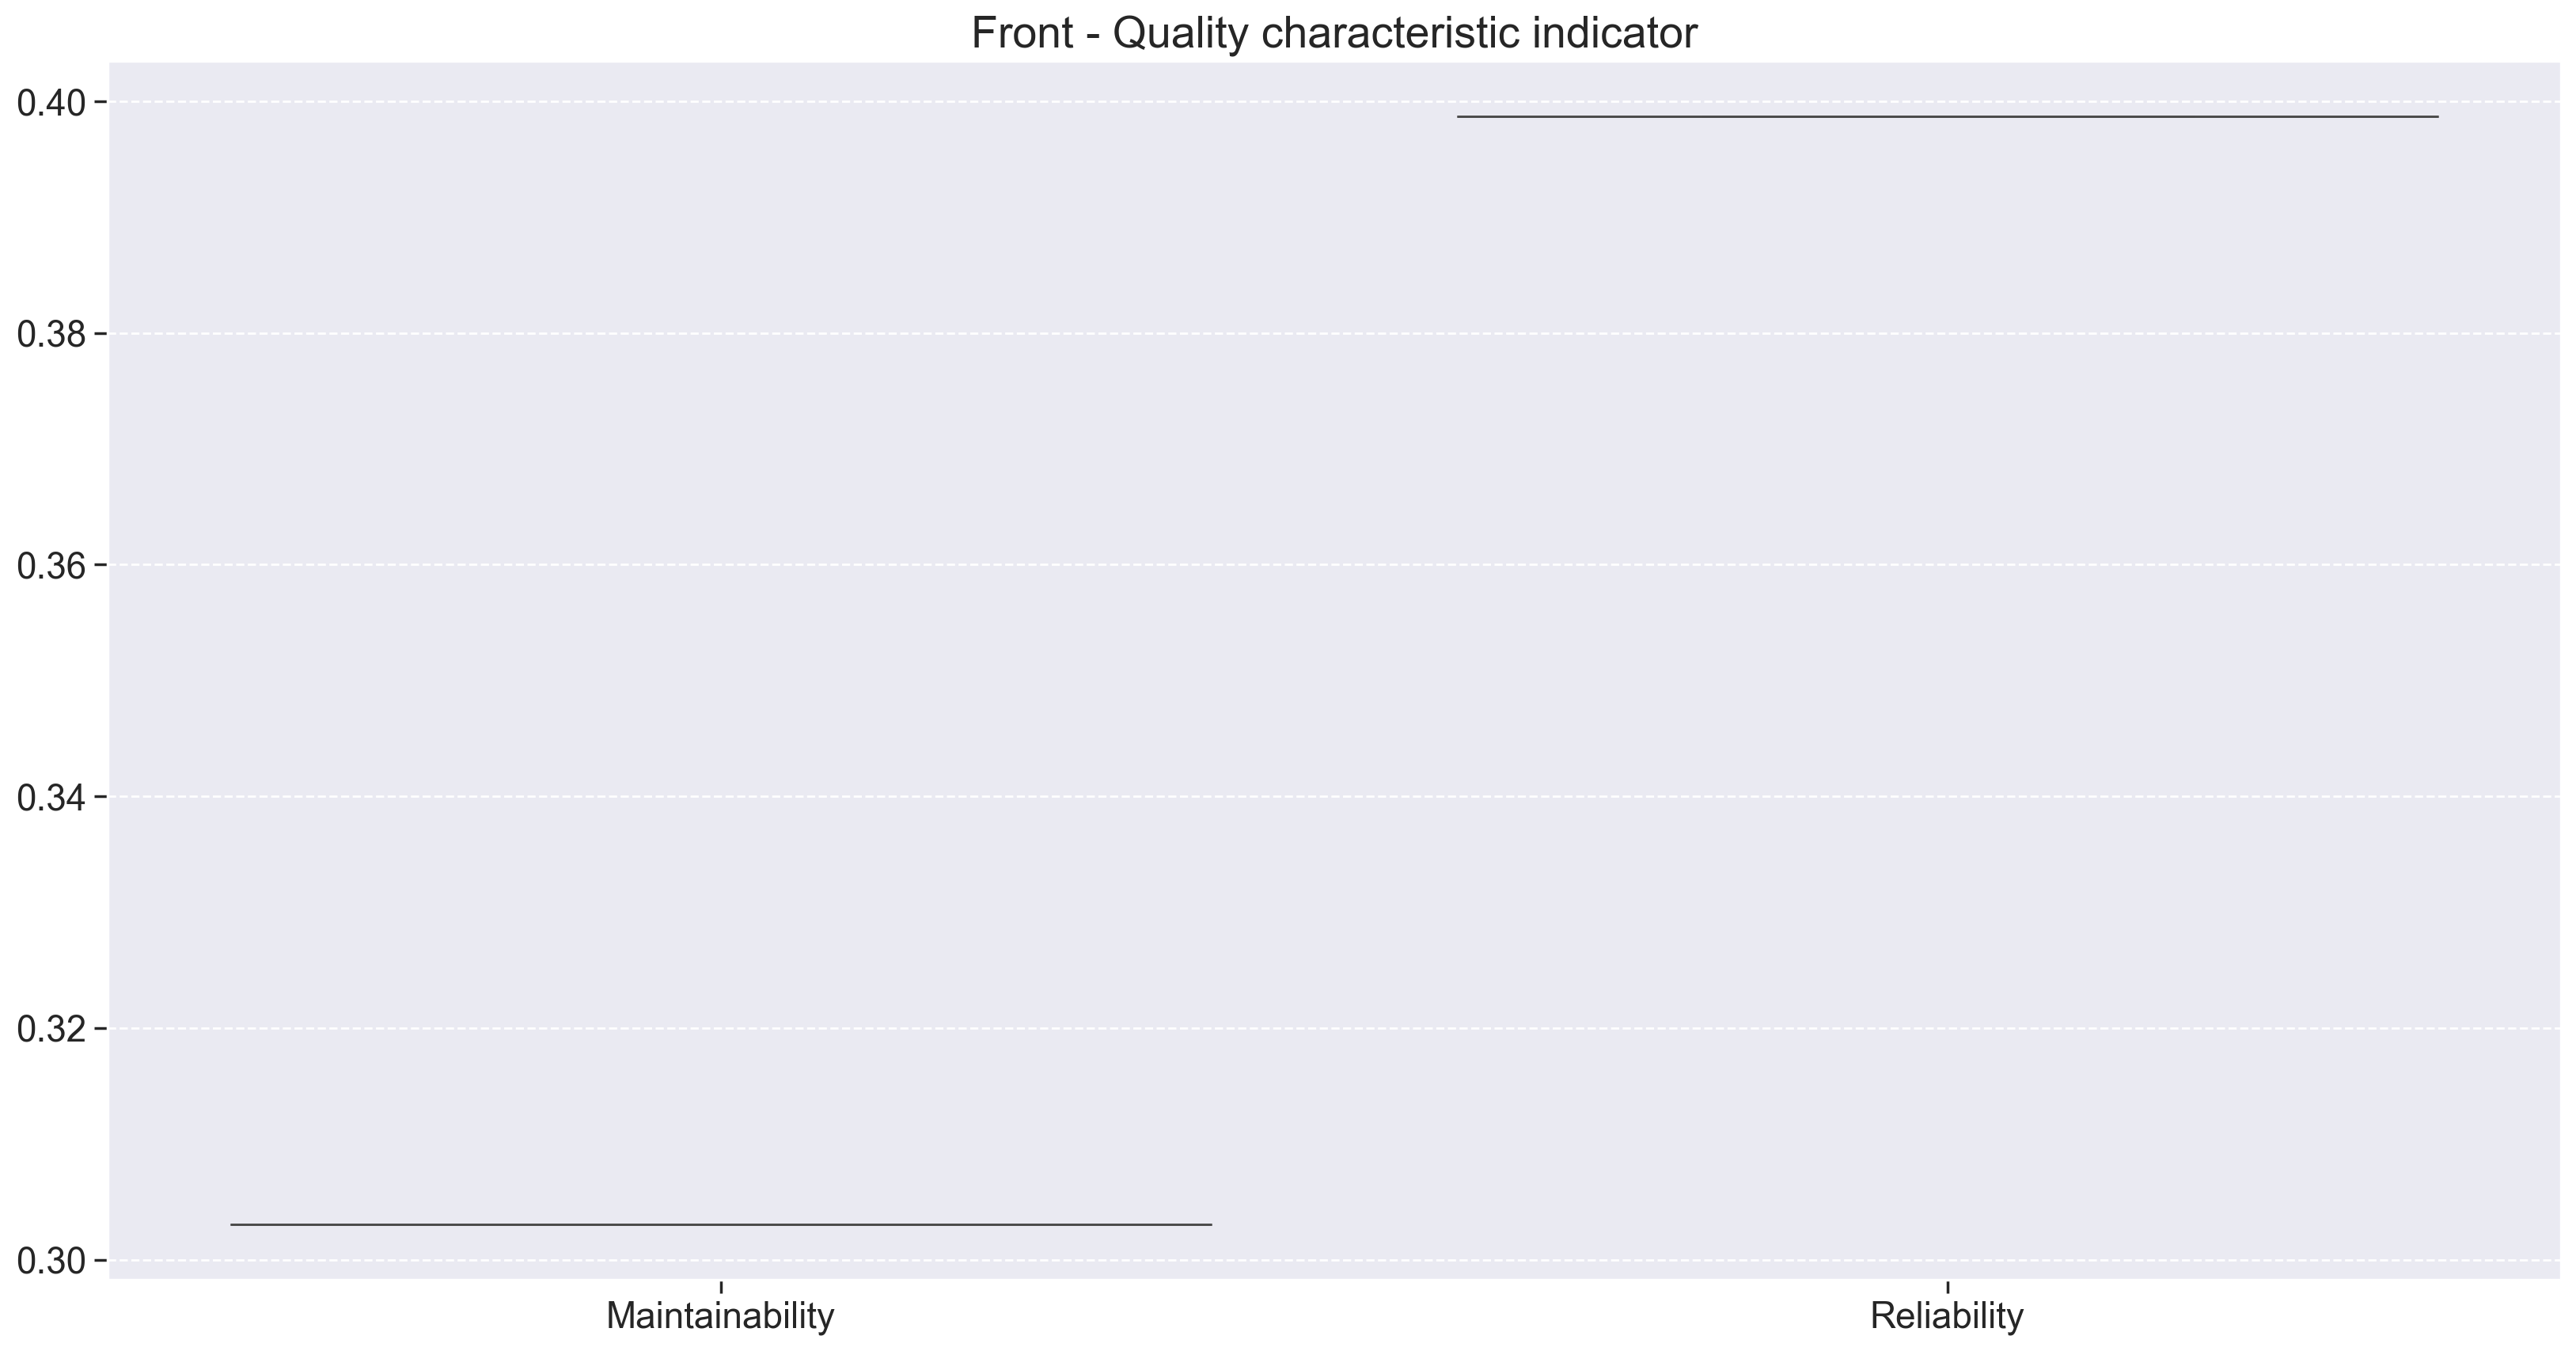

In [92]:

for name, data in metrics.items():
    fig = plt.figure(figsize=(20, 10))
    sns.boxplot(data=data[['Maintainability','Reliability']])

    plt.title(f"{name} - Quality characteristic indicator", fontsize=20)
    plt.show()

### Quality indicator visualization

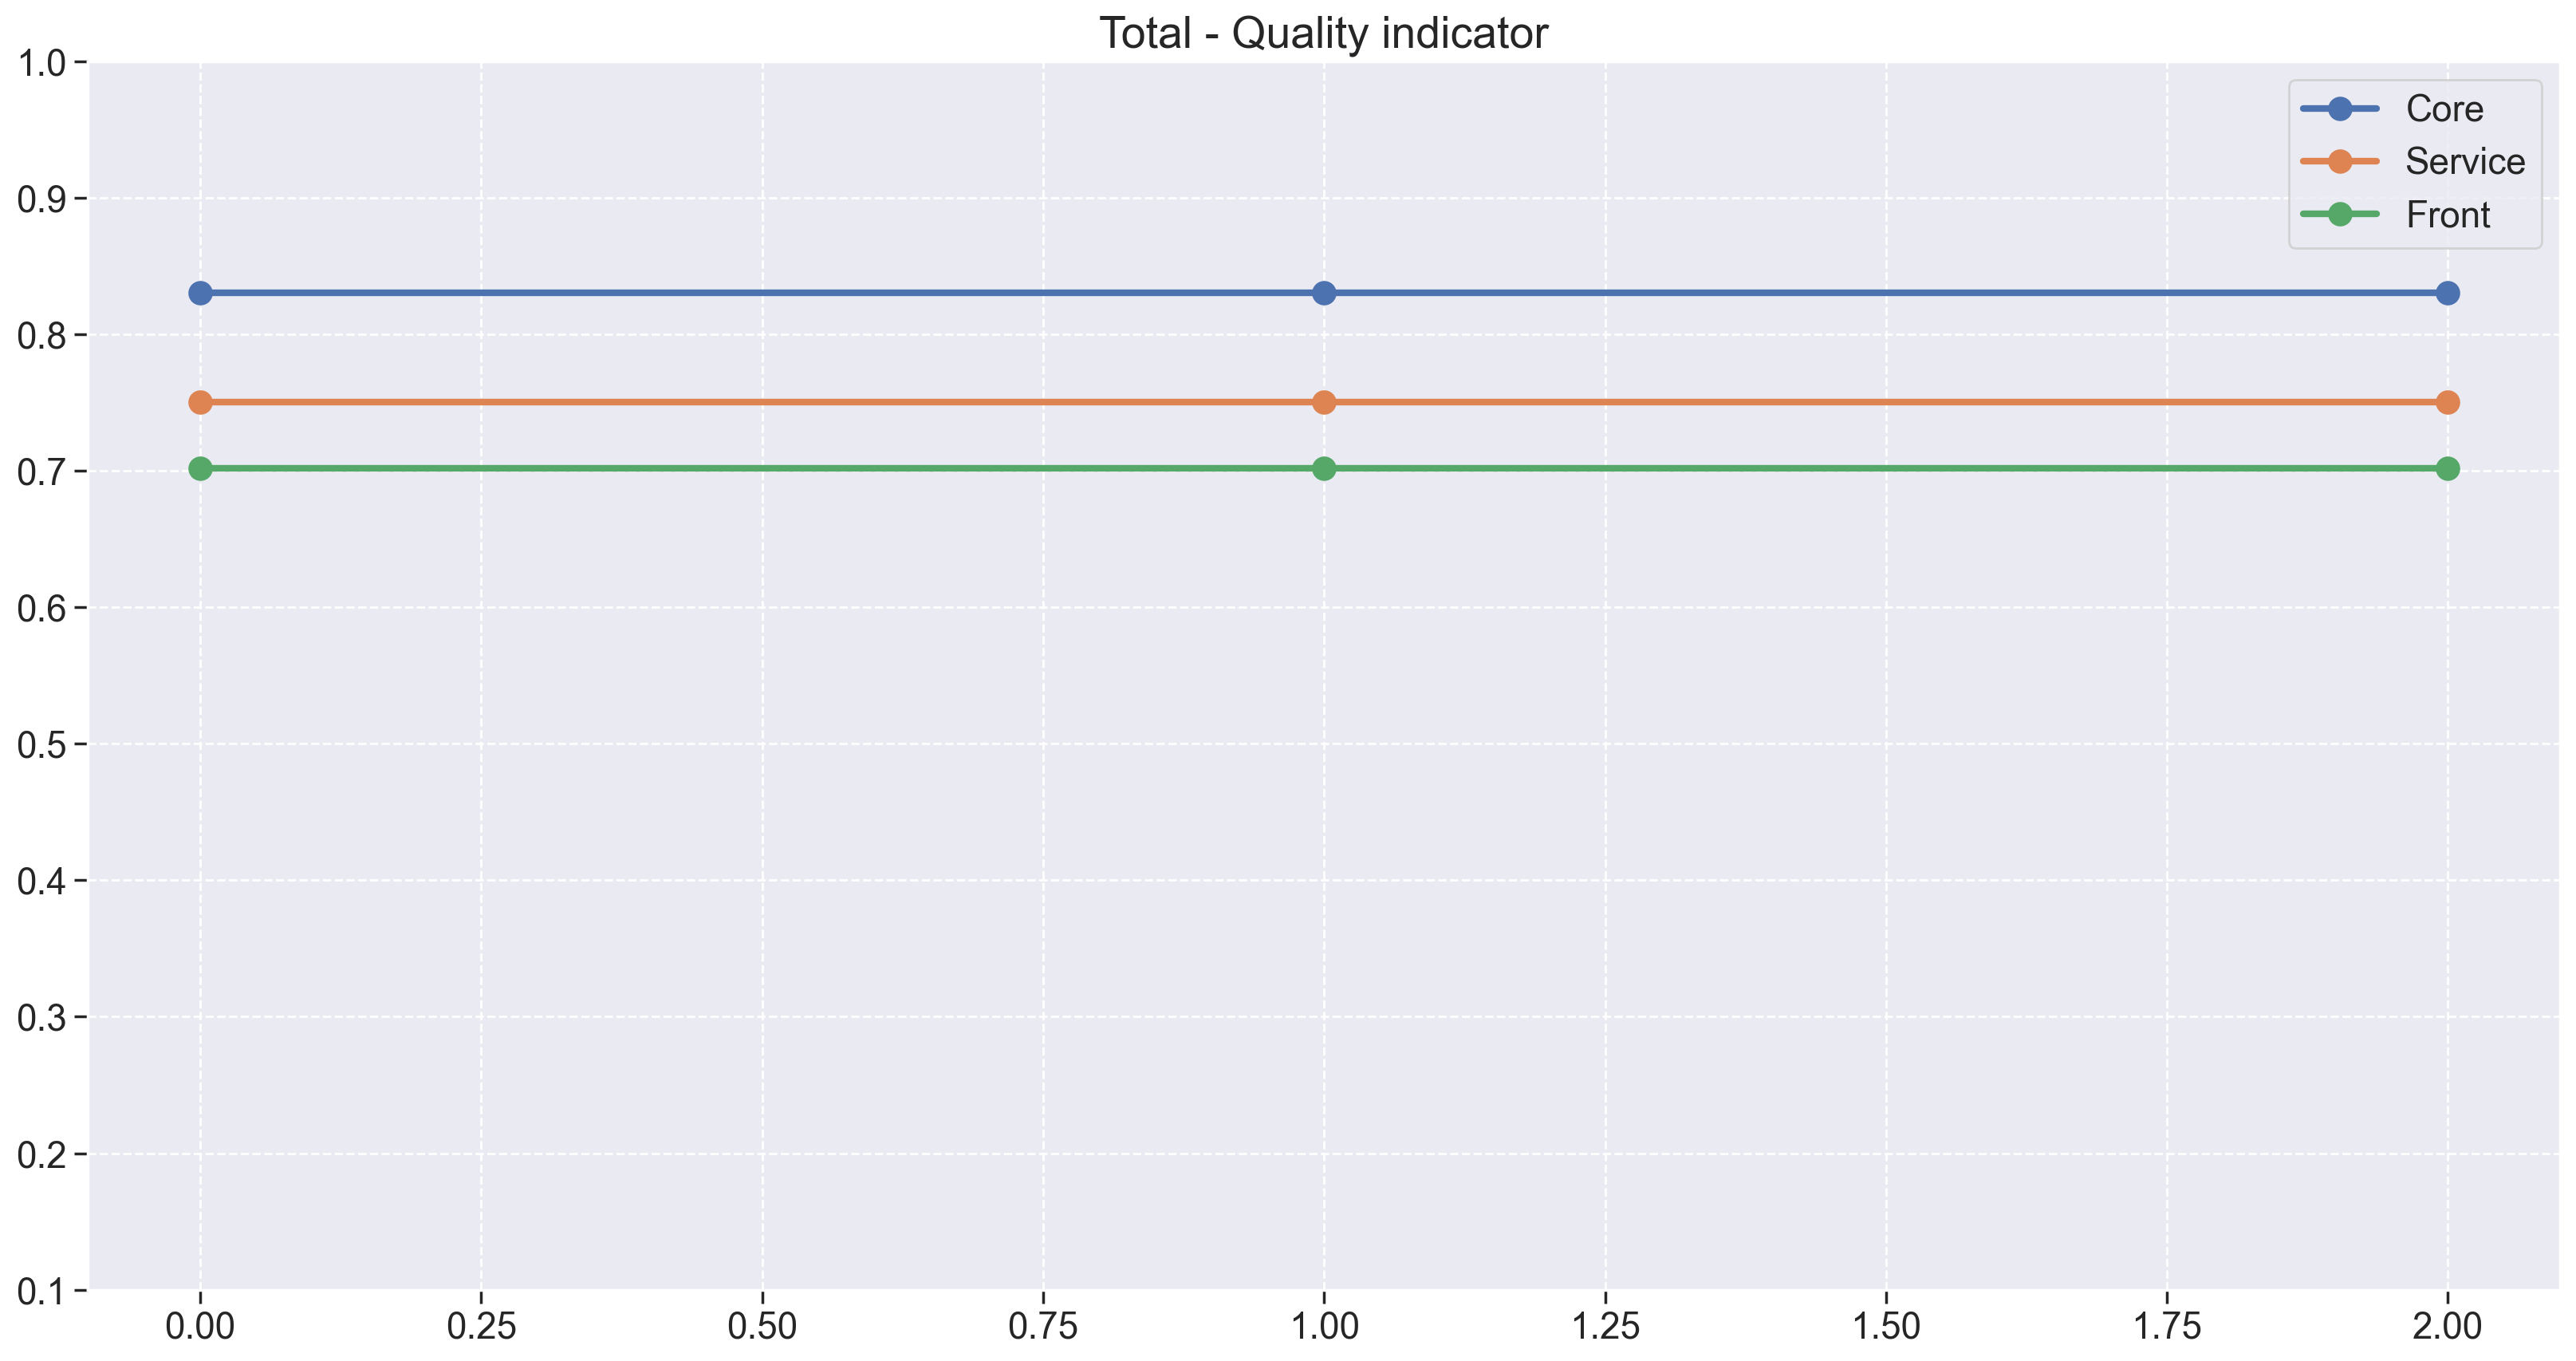

In [93]:
fig = plt.figure(figsize=(20, 10))

for name, data in metrics.items():
    plt.plot(data['total'], linewidth=3, marker='o', markersize=10, label=name)

plt.ylim(.1,1)
plt.title("Total - Quality indicator", fontsize=20)
plt.legend(loc='best')
plt.show()

## Export data

In [94]:
metrics_list = metrics.values()

metrics_df = pd.concat(metrics_list, ignore_index=True)

display(metrics_df)

current_datetime = datetime.datetime.now().strftime("%m-%d-%Y--%H-%M-%S")

metrics_df.to_excel('./data/fga-eps-mds-2022-2-MeasureSoftGram--{}.xlsx'.format(current_datetime), index = False)

metrics_df.to_csv('./data/fga-eps-mds-2022-2-MeasureSoftGram--{}.csv'.format(current_datetime), index = False)

,complexity,comments,duplication,test_success,fast_tests,coverage,bug_density_per_LOC,fulfillment,repository,version,ncloc,code_quality,testing_status,Maintainability,Reliability,total
0,0.777778,0.222222,1.000000,1.0,1.0,1.000000,1.000000,0.555556,fga-eps-mds-2024.1-MeasureSoftGram-Core,02-21-2025-23-56-31,3733,0.660000,1.000000,0.330000,0.500000,0.830000
1,0.777778,0.222222,1.000000,1.0,1.0,1.000000,1.000000,0.555556,fga-eps-mds-2024.1-MeasureSoftGram-Core,02-21-2025-23-56-34,3733,0.660000,1.000000,0.330000,0.500000,0.830000
2,0.777778,0.222222,1.000000,1.0,1.0,1.000000,1.000000,0.555556,fga-eps-mds-2024.1-MeasureSoftGram-Core,02-21-2025-23-56-36,3733,0.660000,1.000000,0.330000,0.500000,0.830000
3,0.459459,0.189189,0.990991,1.0,1.0,0.918919,0.999850,0.090090,fga-eps-mds-2024.1-MeasureSoftGram-Service,02-21-2025-23-54-02,22913,0.541081,0.959459,0.270541,0.479730,0.750270
4,0.459459,0.189189,0.990991,1.0,1.0,0.918919,0.999850,0.090090,fga-eps-mds-2024.1-MeasureSoftGram-Service,02-21-2025-23-54-30,22913,0.541081,0.959459,0.270541,0.479730,0.750270
5,0.459459,0.189189,0.990991,1.0,1.0,0.918919,0.999850,0.090090,fga-eps-mds-2024.1-MeasureSoftGram-Service,02-21-2025-23-54-34,22913,0.541081,0.959459,0.270541,0.479730,0.750270
6,0.869281,0.039216,0.928105,1.0,1.0,0.594771,0.999906,0.143791,fga-eps-mds-2024.1-MeasureSoftGram-Front,02-21-2025-23-57-41,64809,0.606078,0.797386,0.303039,0.398693,0.701732
7,0.869281,0.039216,0.928105,1.0,1.0,0.594771,0.999906,0.143791,fga-eps-mds-2024.1-MeasureSoftGram-Front,02-21-2025-23-57-44,64809,0.606078,0.797386,0.303039,0.398693,0.701732
8,0.869281,0.039216,0.928105,1.0,1.0,0.594771,0.999906,0.143791,fga-eps-mds-2024.1-MeasureSoftGram-Front,02-21-2025-23-57-46,64809,0.606078,0.797386,0.303039,0.398693,0.701732
